# Tahap 07 — Visualization, Interpretation, dan Final Reporting

## Judul Project

**Analisis Komputasional Topik Pidato Presiden Prabowo pada Forum Nasional dan Internasional Menggunakan Manual Coding dan BERTopic**

## Tujuan Notebook

Notebook ini digunakan untuk menyusun hasil akhir project dalam bentuk:

1. Ringkasan final hasil Manual Coding.
2. Ringkasan final hasil BERTopic.
3. Interpretasi komparatif Manual Coding vs BERTopic.
4. Visualisasi final untuk laporan akademik dan presentasi.
5. Narasi ringkas hasil penelitian dalam format Markdown.

## Input Utama

```text
data/processed/comparative_analysis_manual_vs_bertopic.csv
reports/tables/comparative_metrics_summary.csv
reports/tables/bertopic_topic_manual_theme_mapping.csv
reports/tables/manual_theme_bertopic_topic_mapping.csv
reports/tables/comparative_narrative_summary.csv
reports/tables/representative_documents_by_topic.csv
reports/tables/comparative_coverage_report.csv
reports/tables/comparative_crosstab_theme_topic.csv
reports/tables/comparative_crosstab_theme_topic_pct.csv
```

## Output Utama

```text
reports/tables/final_manual_theme_summary.csv
reports/tables/final_bertopic_topic_summary.csv
reports/tables/final_comparative_interpretation.csv
reports/tables/final_key_findings.csv
reports/tables/final_representative_evidence.csv
reports/figures/final_manual_theme_distribution.html
reports/figures/final_bertopic_topic_distribution.html
reports/figures/final_topic_purity_bar.html
reports/figures/final_comparative_heatmap.html
reports/figures/final_manual_theme_topic_alignment.html
reports/final_report_summary.md
reports/final_presentation_notes.md
reports/tables/stage07_output_manifest.json
```

## Catatan

Tahap ini tidak mengubah hasil modeling. Tahap ini hanya merapikan, memvisualisasikan, dan menginterpretasikan output dari Tahap 06.

## 1. Import Library

Library utama:

- Pandas dan NumPy untuk pengolahan tabel.
- Plotly untuk visualisasi HTML.
- Pathlib dan JSON untuk manajemen output.

In [1]:
# ============================================================
# Import Library
# ============================================================

from pathlib import Path
from datetime import datetime
import importlib
import json
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

print("Library dasar berhasil di-import.")
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Library dasar berhasil di-import.
Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
Pandas version: 2.3.3
Numpy version: 2.2.6


## 2. Setup Path Project

Notebook mendeteksi root project berdasarkan file output Tahap 06.

In [2]:
# ============================================================
# Setup Path Project
# ============================================================

def find_project_root(start_path=None):
    """
    Mendeteksi root folder project berdasarkan keberadaan file hasil Tahap 06.
    """
    if start_path is None:
        start_path = Path.cwd().resolve()
    else:
        start_path = Path(start_path).resolve()

    candidate_paths = [start_path] + list(start_path.parents)

    for candidate in candidate_paths:
        expected_input = candidate / "data" / "processed" / "comparative_analysis_manual_vs_bertopic.csv"
        if expected_input.exists():
            return candidate

    return start_path


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORT_TABLE_DIR = REPORTS_DIR / "tables"
REPORT_FIGURE_DIR = REPORTS_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_COMPARATIVE_ANALYSIS = PROCESSED_DIR / "comparative_analysis_manual_vs_bertopic.csv"
INPUT_COMPARATIVE_METRICS = REPORT_TABLE_DIR / "comparative_metrics_summary.csv"
INPUT_TOPIC_MANUAL_MAPPING = REPORT_TABLE_DIR / "bertopic_topic_manual_theme_mapping.csv"
INPUT_MANUAL_TOPIC_MAPPING = REPORT_TABLE_DIR / "manual_theme_bertopic_topic_mapping.csv"
INPUT_NARRATIVE_SUMMARY = REPORT_TABLE_DIR / "comparative_narrative_summary.csv"
INPUT_REPRESENTATIVE_DOCS = REPORT_TABLE_DIR / "representative_documents_by_topic.csv"
INPUT_COVERAGE_REPORT = REPORT_TABLE_DIR / "comparative_coverage_report.csv"
INPUT_CROSSTAB = REPORT_TABLE_DIR / "comparative_crosstab_theme_topic.csv"
INPUT_CROSSTAB_PCT = REPORT_TABLE_DIR / "comparative_crosstab_theme_topic_pct.csv"

print("Project path berhasil disiapkan.")
print(f"Current working directory      : {Path.cwd().resolve()}")
print(f"PROJECT_ROOT                   : {PROJECT_ROOT}")
print(f"INPUT_COMPARATIVE_ANALYSIS     : {INPUT_COMPARATIVE_ANALYSIS}")
print(f"INPUT_COMPARATIVE_METRICS      : {INPUT_COMPARATIVE_METRICS}")
print(f"REPORT_TABLE_DIR               : {REPORT_TABLE_DIR}")
print(f"REPORT_FIGURE_DIR              : {REPORT_FIGURE_DIR}")

Project path berhasil disiapkan.
Current working directory      : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\notebooks
PROJECT_ROOT                   : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech
INPUT_COMPARATIVE_ANALYSIS     : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\data\processed\comparative_analysis_manual_vs_bertopic.csv
INPUT_COMPARATIVE_METRICS      : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\comparative_metrics_summary.csv
REPORT_TABLE_DIR               : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables
REPORT_FIGURE_DIR              : D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures


## 3. Preflight Check Input

Cell ini memastikan seluruh file input Tahap 07 tersedia.

In [3]:
# ============================================================
# Preflight Check Input
# ============================================================

required_input_files = {
    "comparative_analysis_manual_vs_bertopic": INPUT_COMPARATIVE_ANALYSIS,
    "comparative_metrics_summary": INPUT_COMPARATIVE_METRICS,
    "bertopic_topic_manual_theme_mapping": INPUT_TOPIC_MANUAL_MAPPING,
    "manual_theme_bertopic_topic_mapping": INPUT_MANUAL_TOPIC_MAPPING,
    "comparative_narrative_summary": INPUT_NARRATIVE_SUMMARY,
    "representative_documents_by_topic": INPUT_REPRESENTATIVE_DOCS,
    "comparative_coverage_report": INPUT_COVERAGE_REPORT,
    "comparative_crosstab_theme_topic": INPUT_CROSSTAB,
    "comparative_crosstab_theme_topic_pct": INPUT_CROSSTAB_PCT
}

missing_files = []

for name, file_path in required_input_files.items():
    if not file_path.exists():
        missing_files.append((name, file_path))

if missing_files:
    error_message = "File input berikut belum ditemukan:\n"
    for name, file_path in missing_files:
        error_message += f"- {name}: {file_path}\n"
    raise FileNotFoundError(error_message)

print("Seluruh file input Tahap 07 ditemukan.")
for name, file_path in required_input_files.items():
    print(f"- {name}: {file_path.stat().st_size:,} bytes")

Seluruh file input Tahap 07 ditemukan.
- comparative_analysis_manual_vs_bertopic: 152,418 bytes
- comparative_metrics_summary: 510 bytes
- bertopic_topic_manual_theme_mapping: 2,105 bytes
- manual_theme_bertopic_topic_mapping: 1,002 bytes
- comparative_narrative_summary: 6,471 bytes
- representative_documents_by_topic: 107,131 bytes
- comparative_coverage_report: 615 bytes
- comparative_crosstab_theme_topic: 504 bytes
- comparative_crosstab_theme_topic_pct: 774 bytes


## 4. Membaca Dataset Tahap 06

Dataset dari Tahap 06 dibaca untuk disusun menjadi output final.

In [4]:
# ============================================================
# Load Dataset
# ============================================================

comparative_df = pd.read_csv(INPUT_COMPARATIVE_ANALYSIS)
metrics_df = pd.read_csv(INPUT_COMPARATIVE_METRICS)
topic_manual_mapping_df = pd.read_csv(INPUT_TOPIC_MANUAL_MAPPING)
manual_topic_mapping_df = pd.read_csv(INPUT_MANUAL_TOPIC_MAPPING)
narrative_summary_df = pd.read_csv(INPUT_NARRATIVE_SUMMARY)
representative_docs_df = pd.read_csv(INPUT_REPRESENTATIVE_DOCS)
coverage_report_df = pd.read_csv(INPUT_COVERAGE_REPORT)
crosstab_df = pd.read_csv(INPUT_CROSSTAB)
crosstab_pct_df = pd.read_csv(INPUT_CROSSTAB_PCT)

print("Dataset Tahap 06 berhasil dibaca.")
print(f"comparative_df shape           : {comparative_df.shape}")
print(f"metrics_df shape               : {metrics_df.shape}")
print(f"topic_manual_mapping_df shape  : {topic_manual_mapping_df.shape}")
print(f"manual_topic_mapping_df shape  : {manual_topic_mapping_df.shape}")
print(f"narrative_summary_df shape     : {narrative_summary_df.shape}")
print(f"representative_docs_df shape   : {representative_docs_df.shape}")
print(f"coverage_report_df shape       : {coverage_report_df.shape}")
print(f"crosstab_df shape              : {crosstab_df.shape}")
print(f"crosstab_pct_df shape          : {crosstab_pct_df.shape}")

display(comparative_df.head())

Dataset Tahap 06 berhasil dibaca.
comparative_df shape           : (71, 31)
metrics_df shape               : (5, 3)
topic_manual_mapping_df shape  : (15, 7)
manual_topic_mapping_df shape  : (6, 7)
narrative_summary_df shape     : (15, 9)
representative_docs_df shape   : (59, 12)
coverage_report_df shape       : (7, 3)
crosstab_df shape              : (6, 16)
crosstab_pct_df shape          : (6, 16)


,doc_id,speech_id,file_name,speech_title_from_filename,forum_scope_inferred,event_date,language_estimate,chunk_order,text,chunk_word_count,...,manual_selective_theme,coding_status,coder_notes,manual_selective_theme_clean,manual_axial_category_clean,manual_open_code_1_clean,coding_status_clean,bertopic_topic_id_clean,bertopic_topic_name_from_info,bertopic_auto_topic_label
0,SPCH_001_BRICS_LEADERS_CHK_001,SPCH_001_BRICS_LEADERS,NASKAH-PIDATO-PRABOWO-BRICS-LEADERS.txt,Brics Leaders,international,2025-09-08,en,1,Distinguished Leaders of BRICS. It is indeed a...,227,...,"Diplomasi, perdamaian, dan keadilan global",REVIEWED,NaN,"Diplomasi, perdamaian, dan keadilan global",Diplomasi dan tatanan global,Diplomasi multilateral dan kerja sama internas...,REVIEWED,9,9_brics_best_danantara_now,brics / best / danantara / now / biggest
1,SPCH_001_BRICS_LEADERS_CHK_002,SPCH_001_BRICS_LEADERS,NASKAH-PIDATO-PRABOWO-BRICS-LEADERS.txt,Brics Leaders,international,2025-09-08,en,2,"We consider now, this is the time that BRICS m...",42,...,"Diplomasi, perdamaian, dan keadilan global",REVIEWED,NaN,"Diplomasi, perdamaian, dan keadilan global",Diplomasi dan tatanan global,Diplomasi multilateral dan kerja sama internas...,REVIEWED,9,9_brics_best_danantara_now,brics / best / danantara / now / biggest
2,SPCH_002_PANEN_RAYA_CHK_001,SPCH_002_PANEN_RAYA,NASKAH-PIDATO-PRABOWO-PANEN-RAYA.txt,Panen Raya,national,2026-01-07,id,1,Bismillahirrahmanirrahim. Assalamu'alaikum war...,268,...,Kedaulatan dan kemandirian nasional,REVIEWED,NaN,Kedaulatan dan kemandirian nasional,Ketahanan nasional dan kedaulatan strategis,Kedaulatan pangan dan swasembada,REVIEWED,0,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota
3,SPCH_002_PANEN_RAYA_CHK_002,SPCH_002_PANEN_RAYA,NASKAH-PIDATO-PRABOWO-PANEN-RAYA.txt,Panen Raya,national,2026-01-07,id,2,"Yang saya hormati, para Dirut BUMN yang berken...",224,...,Kedaulatan dan kemandirian nasional,REVIEWED,NaN,Kedaulatan dan kemandirian nasional,Ketahanan nasional dan kedaulatan strategis,Kedaulatan pangan dan swasembada,REVIEWED,0,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota
4,SPCH_002_PANEN_RAYA_CHK_004,SPCH_002_PANEN_RAYA,NASKAH-PIDATO-PRABOWO-PANEN-RAYA.txt,Panen Raya,national,2026-01-07,id,4,"Walaupun selalu, kita selalu ingat saudara-sau...",222,...,Kedaulatan dan kemandirian nasional,REVIEWED,NaN,Kedaulatan dan kemandirian nasional,Identitas nasional dan kepemimpinan,Persatuan nasional dan kepercayaan diri bangsa,REVIEWED,10,10_sudah_proyek_mengerti_juta,sudah / proyek / mengerti / juta / sembilan


## 5. Validasi Kolom Wajib

Validasi dilakukan agar notebook tidak bergantung pada asumsi kolom.

In [5]:
# ============================================================
# Helper Validasi Kolom
# ============================================================

def require_columns(df, required_columns, df_name="DataFrame"):
    """
    Memastikan DataFrame memiliki kolom yang dibutuhkan.
    """
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            f"{df_name} tidak memiliki kolom wajib: {missing_columns}. "
            f"Kolom tersedia: {list(df.columns)}"
        )


def metric_value(metrics_table, metric_name, default_value=None):
    """
    Mengambil nilai metric tertentu dari comparative_metrics_summary.
    """
    if "metric" not in metrics_table.columns or "value" not in metrics_table.columns:
        return default_value

    matched = metrics_table.loc[metrics_table["metric"] == metric_name, "value"]

    if matched.empty:
        return default_value

    return matched.iloc[0]


def coverage_value(coverage_table, metric_name, default_value=None):
    """
    Mengambil nilai metric tertentu dari comparative_coverage_report.
    """
    if "metric" not in coverage_table.columns or "value" not in coverage_table.columns:
        return default_value

    matched = coverage_table.loc[coverage_table["metric"] == metric_name, "value"]

    if matched.empty:
        return default_value

    return matched.iloc[0]


REQUIRED_COMPARATIVE_COLUMNS = [
    "doc_id",
    "speech_id",
    "text",
    "bertopic_topic_id",
    "manual_selective_theme_clean",
    "manual_axial_category_clean",
    "manual_open_code_1_clean"
]

REQUIRED_METRICS_COLUMNS = [
    "metric",
    "value",
    "interpretation"
]

REQUIRED_TOPIC_MANUAL_MAPPING_COLUMNS = [
    "bertopic_topic_id",
    "dominant_manual_selective_theme",
    "dominant_theme_count",
    "topic_document_count",
    "topic_purity"
]

REQUIRED_MANUAL_TOPIC_MAPPING_COLUMNS = [
    "manual_selective_theme_clean",
    "dominant_bertopic_topic_id",
    "dominant_topic_count",
    "theme_document_count",
    "theme_concentration"
]

REQUIRED_NARRATIVE_COLUMNS = [
    "bertopic_topic_id",
    "top_keywords",
    "dominant_manual_selective_theme",
    "topic_document_count",
    "topic_purity"
]

REQUIRED_REPRESENTATIVE_COLUMNS = [
    "doc_id",
    "bertopic_topic_id",
    "manual_selective_theme",
    "text"
]

require_columns(comparative_df, REQUIRED_COMPARATIVE_COLUMNS, "comparative_df")
require_columns(metrics_df, REQUIRED_METRICS_COLUMNS, "metrics_df")
require_columns(topic_manual_mapping_df, REQUIRED_TOPIC_MANUAL_MAPPING_COLUMNS, "topic_manual_mapping_df")
require_columns(manual_topic_mapping_df, REQUIRED_MANUAL_TOPIC_MAPPING_COLUMNS, "manual_topic_mapping_df")
require_columns(narrative_summary_df, REQUIRED_NARRATIVE_COLUMNS, "narrative_summary_df")
require_columns(representative_docs_df, REQUIRED_REPRESENTATIVE_COLUMNS, "representative_docs_df")

print("Validasi kolom wajib berhasil.")

Validasi kolom wajib berhasil.


## 6. Final Manual Theme Summary

Tabel ini merangkum hasil Manual Coding pada level tema utama.

In [6]:
# ============================================================
# Final Manual Theme Summary
# ============================================================

aggregation_dict = {
    "document_count": ("doc_id", "count"),
    "unique_speech_count": ("speech_id", "nunique"),
    "unique_bertopic_topic_count": ("bertopic_topic_id", "nunique")
}

if "bertopic_topic_probability" in comparative_df.columns:
    aggregation_dict["avg_bertopic_probability"] = ("bertopic_topic_probability", "mean")

final_manual_theme_summary_df = (
    comparative_df
    .groupby("manual_selective_theme_clean", dropna=False)
    .agg(**aggregation_dict)
    .reset_index()
)

if "avg_bertopic_probability" in final_manual_theme_summary_df.columns:
    final_manual_theme_summary_df["avg_bertopic_probability"] = (
        final_manual_theme_summary_df["avg_bertopic_probability"].round(4)
    )

manual_total_docs = final_manual_theme_summary_df["document_count"].sum()
final_manual_theme_summary_df["document_percentage"] = (
    final_manual_theme_summary_df["document_count"] / manual_total_docs * 100
).round(2)

final_manual_theme_summary_df = final_manual_theme_summary_df.sort_values(
    "document_count",
    ascending=False
).reset_index(drop=True)

display(final_manual_theme_summary_df)

,manual_selective_theme_clean,document_count,unique_speech_count,unique_bertopic_topic_count,avg_bertopic_probability,document_percentage
0,Pembangunan manusia dan keadilan sosial,24,4,12,0.6661,33.80
1,Kedaulatan dan kemandirian nasional,22,5,8,0.7423,30.99
2,"Diplomasi, perdamaian, dan keadilan global",12,3,6,0.8664,16.90
3,Reformasi tata kelola dan penegakan hukum,6,4,5,0.7384,8.45
4,Transformasi ekonomi dan pembangunan nasional,5,3,5,0.8337,7.04
5,Keberlanjutan lingkungan dan sumber daya,2,2,2,0.5499,2.82


## 7. Final BERTopic Topic Summary

Tabel ini merangkum hasil BERTopic dan hubungannya dengan tema manual dominan.

In [7]:
# ============================================================
# Final BERTopic Topic Summary
# ============================================================

final_bertopic_topic_summary_df = topic_manual_mapping_df.copy()

# Tambahkan keyword ringkas jika tersedia dari narrative_summary.
keyword_cols = ["bertopic_topic_id", "top_keywords"]
if all(col in narrative_summary_df.columns for col in keyword_cols):
    final_bertopic_topic_summary_df = final_bertopic_topic_summary_df.merge(
        narrative_summary_df[keyword_cols],
        on="bertopic_topic_id",
        how="left"
    )

final_bertopic_topic_summary_df["topic_type"] = np.where(
    final_bertopic_topic_summary_df["bertopic_topic_id"].astype(str) == "-1",
    "Outlier",
    "Cluster"
)

final_bertopic_topic_summary_df = final_bertopic_topic_summary_df.sort_values(
    ["topic_type", "topic_document_count"],
    ascending=[True, False]
).reset_index(drop=True)

display(final_bertopic_topic_summary_df)

,bertopic_topic_id,dominant_manual_selective_theme,dominant_theme_count,topic_document_count,topic_purity,Name,auto_topic_label,top_keywords,topic_type
0,0,Kedaulatan dan kemandirian nasional,8,13,0.6154,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota,"bupati, hadir, menteri, hormati, wali kota, wa...",Cluster
1,1,"Diplomasi, perdamaian, dan keadilan global",2,7,0.2857,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,"kampus, stability, growth, peace stability, ov...",Cluster
2,2,Kedaulatan dan kemandirian nasional,4,6,0.6667,2_energi_menghasilkan_kesulitan_hasilkan,energi / menghasilkan / kesulitan / hasilkan /...,"energi, menghasilkan, kesulitan, hasilkan, ter...",Cluster
3,3,Kedaulatan dan kemandirian nasional,3,6,0.5000,3_000_rice_years_000 murid,000 / rice / years / 000 murid / 83,"000, rice, years, 000 murid, 83, 83 000, sasar...",Cluster
4,4,Pembangunan manusia dan keadilan sosial,3,5,0.6000,4_kemerdekaan_dia_perang_mau,kemerdekaan / dia / perang / mau / enggak,"kemerdekaan, dia, perang, mau, enggak, rakyat,...",Cluster
5,5,Kedaulatan dan kemandirian nasional,3,5,0.6000,5_swasembada_amran_harga_tokoh,swasembada / amran / harga / tokoh / kulitnya,"swasembada, amran, harga, tokoh, kulitnya, jad...",Cluster
6,6,Pembangunan manusia dan keadilan sosial,4,4,1.0000,6_anak_orang tuamu_tuamu_son,anak / orang tuamu / tuamu / son / kau,"anak, orang tuamu, tuamu, son, kau, ya, anak a...",Cluster
7,7,"Diplomasi, perdamaian, dan keadilan global",4,4,1.0000,7_united nations_nations_united_peace,united nations / nations / united / peace / all,"united nations, nations, united, peace, all, t...",Cluster
8,8,Pembangunan manusia dan keadilan sosial,3,4,0.7500,8_koperasi_meals_day_guru,koperasi / meals / day / guru / desember,"koperasi, meals, day, guru, desember, ribu, ko...",Cluster
9,9,"Diplomasi, perdamaian, dan keadilan global",2,3,0.6667,9_brics_best_danantara_now,brics / best / danantara / now / biggest,"brics, best, danantara, now, biggest, fully su...",Cluster


## 8. Final Comparative Interpretation

Tabel ini menyusun interpretasi komparatif antara tema manual dan topik BERTopic.

Interpretasi dibangun dari:

- Tema manual dominan.
- Topik BERTopic dominan.
- Nilai concentration atau purity.
- Kata kunci topik.

In [8]:
# ============================================================
# Final Comparative Interpretation
# ============================================================

final_comparative_interpretation_df = manual_topic_mapping_df.copy()

topic_keyword_lookup = {}

if "bertopic_topic_id" in narrative_summary_df.columns and "top_keywords" in narrative_summary_df.columns:
    topic_keyword_lookup = dict(
        zip(
            narrative_summary_df["bertopic_topic_id"].astype(str),
            narrative_summary_df["top_keywords"].fillna("")
        )
    )

def classify_alignment(concentration):
    """
    Mengklasifikasikan tingkat alignment berdasarkan theme_concentration.
    """
    try:
        concentration = float(concentration)
    except Exception:
        return "Tidak diketahui"

    if concentration >= 0.70:
        return "Kuat"
    if concentration >= 0.40:
        return "Sedang"

    return "Lemah"


def build_comparative_note(row):
    theme = row["manual_selective_theme_clean"]
    topic_id = row["dominant_bertopic_topic_id"]
    concentration = row["theme_concentration"]
    topic_count = row["dominant_topic_count"]
    theme_count = row["theme_document_count"]
    keywords = topic_keyword_lookup.get(str(topic_id), "")

    alignment = classify_alignment(concentration)

    return (
        f"Tema manual '{theme}' paling sering dipetakan ke BERTopic Topic {topic_id} "
        f"dengan {topic_count} dari {theme_count} chunk. "
        f"Tingkat alignment dikategorikan {alignment.lower()} "
        f"(theme concentration={concentration}). "
        f"Keyword topik dominan: {keywords}."
    )

final_comparative_interpretation_df["alignment_level"] = (
    final_comparative_interpretation_df["theme_concentration"].apply(classify_alignment)
)

final_comparative_interpretation_df["interpretation_note"] = (
    final_comparative_interpretation_df.apply(build_comparative_note, axis=1)
)

final_comparative_interpretation_df = final_comparative_interpretation_df.sort_values(
    ["theme_document_count"],
    ascending=False
).reset_index(drop=True)

display(final_comparative_interpretation_df)

,manual_selective_theme_clean,dominant_bertopic_topic_id,dominant_topic_count,theme_document_count,theme_concentration,dominant_bertopic_topic_name,auto_topic_label,alignment_level,interpretation_note
0,Pembangunan manusia dan keadilan sosial,6,4,24,0.1667,6_anak_orang tuamu_tuamu_son,anak / orang tuamu / tuamu / son / kau,Lemah,Tema manual 'Pembangunan manusia dan keadilan ...
1,Kedaulatan dan kemandirian nasional,0,8,22,0.3636,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota,Lemah,Tema manual 'Kedaulatan dan kemandirian nasion...
2,"Diplomasi, perdamaian, dan keadilan global",7,4,12,0.3333,7_united nations_nations_united_peace,united nations / nations / united / peace / all,Lemah,"Tema manual 'Diplomasi, perdamaian, dan keadil..."
3,Reformasi tata kelola dan penegakan hukum,1,2,6,0.3333,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,Lemah,Tema manual 'Reformasi tata kelola dan penegak...
4,Transformasi ekonomi dan pembangunan nasional,1,1,5,0.2000,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,Lemah,Tema manual 'Transformasi ekonomi dan pembangu...
5,Keberlanjutan lingkungan dan sumber daya,-1,1,2,0.5000,-1_melindungi_ancaman_melindungi ancaman_pertu...,Outlier / tidak terklaster,Sedang,Tema manual 'Keberlanjutan lingkungan dan sumb...


## 9. Final Key Findings

Cell ini menyusun temuan kunci dalam format tabel yang dapat digunakan untuk laporan dan presentasi.

In [9]:
# ============================================================
# Final Key Findings
# ============================================================

manual_total_chunk_count = coverage_value(coverage_report_df, "manual_total_chunk_count", len(comparative_df))
manual_reviewed_chunk_count = coverage_value(coverage_report_df, "manual_reviewed_chunk_count", len(comparative_df))
manual_excluded_chunk_count = coverage_value(coverage_report_df, "manual_excluded_chunk_count", 0)
bertopic_modeled_document_count = coverage_value(coverage_report_df, "bertopic_modeled_document_count", len(comparative_df))

topic_count = int(topic_manual_mapping_df["bertopic_topic_id"].nunique())
non_outlier_topic_count = int((topic_manual_mapping_df["bertopic_topic_id"].astype(str) != "-1").sum())
outlier_topic_count = int((comparative_df["bertopic_topic_id"].astype(str) == "-1").sum())

nmi = metric_value(metrics_df, "normalized_mutual_information", None)
ami = metric_value(metrics_df, "adjusted_mutual_information", None)
homogeneity = metric_value(metrics_df, "homogeneity", None)
completeness = metric_value(metrics_df, "completeness", None)
v_measure = metric_value(metrics_df, "v_measure", None)

dominant_manual_theme = final_manual_theme_summary_df.iloc[0]["manual_selective_theme_clean"]
dominant_manual_theme_count = int(final_manual_theme_summary_df.iloc[0]["document_count"])

largest_topic_row = final_bertopic_topic_summary_df.sort_values(
    "topic_document_count",
    ascending=False
).iloc[0]

largest_topic_id = largest_topic_row["bertopic_topic_id"]
largest_topic_count = int(largest_topic_row["topic_document_count"])
largest_topic_theme = largest_topic_row["dominant_manual_selective_theme"]

strongest_alignment_row = final_comparative_interpretation_df.sort_values(
    "theme_concentration",
    ascending=False
).iloc[0]

final_key_findings_records = [
    {
        "finding_id": "KF01",
        "finding_title": "Jumlah data analisis final",
        "finding_description": (
            f"Manual Coding mencakup {manual_total_chunk_count} chunk, "
            f"dengan {manual_reviewed_chunk_count} chunk berstatus REVIEWED dan "
            f"{manual_excluded_chunk_count} chunk berstatus EXCLUDED. "
            f"BERTopic dijalankan pada {bertopic_modeled_document_count} chunk substantif."
        )
    },
    {
        "finding_id": "KF02",
        "finding_title": "Tema manual paling dominan",
        "finding_description": (
            f"Tema manual paling dominan adalah '{dominant_manual_theme}' "
            f"dengan {dominant_manual_theme_count} chunk."
        )
    },
    {
        "finding_id": "KF03",
        "finding_title": "Jumlah topik BERTopic",
        "finding_description": (
            f"BERTopic menghasilkan {topic_count} label topik termasuk outlier. "
            f"Jumlah topik non-outlier adalah {non_outlier_topic_count}, "
            f"sedangkan jumlah dokumen pada topik outlier -1 adalah {outlier_topic_count}."
        )
    },
    {
        "finding_id": "KF04",
        "finding_title": "Topik BERTopic terbesar",
        "finding_description": (
            f"Topik BERTopic terbesar adalah Topic {largest_topic_id} dengan "
            f"{largest_topic_count} chunk dan dominan berkaitan dengan tema manual "
            f"'{largest_topic_theme}'."
        )
    },
    {
        "finding_id": "KF05",
        "finding_title": "Tema dengan alignment terkuat",
        "finding_description": (
            f"Alignment terkuat muncul pada tema manual "
            f"'{strongest_alignment_row['manual_selective_theme_clean']}' "
            f"dengan dominant BERTopic Topic {strongest_alignment_row['dominant_bertopic_topic_id']} "
            f"dan theme concentration {strongest_alignment_row['theme_concentration']}."
        )
    },
    {
        "finding_id": "KF06",
        "finding_title": "Kesesuaian Manual Coding dan BERTopic",
        "finding_description": (
            f"Metrik clustering menunjukkan NMI={nmi}, AMI={ami}, "
            f"Homogeneity={homogeneity}, Completeness={completeness}, dan V-measure={v_measure}. "
            f"Nilai ini menunjukkan tingkat hubungan antara tema manual dan struktur topik BERTopic, "
            f"bukan akurasi klasifikasi."
        )
    }
]

final_key_findings_df = pd.DataFrame(final_key_findings_records)

display(final_key_findings_df)

,finding_id,finding_title,finding_description
0,KF01,Jumlah data analisis final,"Manual Coding mencakup 74 chunk, dengan 71 chu..."
1,KF02,Tema manual paling dominan,Tema manual paling dominan adalah 'Pembangunan...
2,KF03,Jumlah topik BERTopic,BERTopic menghasilkan 15 label topik termasuk ...
3,KF04,Topik BERTopic terbesar,Topik BERTopic terbesar adalah Topic 0 dengan ...
4,KF05,Tema dengan alignment terkuat,Alignment terkuat muncul pada tema manual 'Keb...
5,KF06,Kesesuaian Manual Coding dan BERTopic,"Metrik clustering menunjukkan NMI=0.334, AMI=0..."


## 10. Final Representative Evidence

Tabel ini memilih contoh evidence atau chunk representatif untuk setiap topik.

Tujuannya agar laporan tidak hanya menampilkan angka, tetapi juga contoh teks yang mendukung interpretasi.

In [10]:
# ============================================================
# Final Representative Evidence
# ============================================================

final_representative_evidence_df = representative_docs_df.copy()

# Ambil maksimal 3 dokumen per topic untuk ringkasan final.
sort_columns = ["bertopic_topic_id"]
ascending_values = [True]

if "bertopic_topic_probability" in final_representative_evidence_df.columns:
    sort_columns.append("bertopic_topic_probability")
    ascending_values.append(False)

final_representative_evidence_df = (
    final_representative_evidence_df
    .sort_values(sort_columns, ascending=ascending_values)
    .groupby("bertopic_topic_id", dropna=False)
    .head(3)
    .copy()
)

# Buat excerpt agar mudah ditampilkan pada laporan.
def make_excerpt(text, max_chars=280):
    text = str(text).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "..."

final_representative_evidence_df["text_excerpt"] = (
    final_representative_evidence_df["text"].apply(make_excerpt)
)

evidence_columns = [
    "doc_id",
    "speech_id" if "speech_id" in final_representative_evidence_df.columns else None,
    "chunk_order" if "chunk_order" in final_representative_evidence_df.columns else None,
    "bertopic_topic_id",
    "bertopic_topic_name" if "bertopic_topic_name" in final_representative_evidence_df.columns else None,
    "bertopic_topic_probability" if "bertopic_topic_probability" in final_representative_evidence_df.columns else None,
    "manual_open_code_1" if "manual_open_code_1" in final_representative_evidence_df.columns else None,
    "manual_axial_category" if "manual_axial_category" in final_representative_evidence_df.columns else None,
    "manual_selective_theme",
    "text_excerpt"
]

evidence_columns = [col for col in evidence_columns if col is not None]
final_representative_evidence_df = final_representative_evidence_df[evidence_columns].copy()

display(final_representative_evidence_df.head(20))

,doc_id,speech_id,chunk_order,bertopic_topic_id,bertopic_topic_name,bertopic_topic_probability,manual_open_code_1,manual_axial_category,manual_selective_theme,text_excerpt
0,SPCH_006_PBB_80_CHK_006,SPCH_006_PBB_80,6,-1,-1_melindungi_ancaman_melindungi ancaman_pertu...,0.099832,"Lingkungan, iklim, dan keberlanjutan",Ketahanan lingkungan dan keberlanjutan,Keberlanjutan lingkungan dan sumber daya,We aim to achieve net zero emission by 2060 an...
1,SPCH_004_PERESMIAN_166_SEKOLAH_CHK_006,SPCH_004_PERESMIAN_166_SEKOLAH,6,-1,-1_melindungi_ancaman_melindungi ancaman_pertu...,0.086919,Pemerataan kesejahteraan dan pengentasan kemis...,Kesejahteraan sosial dan pemerataan pembangunan,Pembangunan manusia dan keadilan sosial,"Nah, ini teori, tapi kenyataannya menetesnya k..."
2,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_001,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,1,0,0_bupati_hadir_menteri_hormati,1.000000,Kedaulatan energi dan pengelolaan sumber daya,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Bismillahirrahmanirrahim. Assalamu'alaikum war...
3,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_012,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,12,0,0_bupati_hadir_menteri_hormati,1.000000,Kedaulatan energi dan pengelolaan sumber daya,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Advanced technology ini dipimpin oleh seorang ...
4,SPCH_004_PERESMIAN_166_SEKOLAH_CHK_001,SPCH_004_PERESMIAN_166_SEKOLAH,1,0,0_bupati_hadir_menteri_hormati,1.000000,Persatuan nasional dan kepercayaan diri bangsa,Identitas nasional dan kepemimpinan,Kedaulatan dan kemandirian nasional,"Bismillahirrahmanirrahim, Assalamu'alaikum war..."
7,SPCH_005_WORLD_ECONOMIC_FORUM_CHK_001,SPCH_005_WORLD_ECONOMIC_FORUM,1,1,1_kampus_stability_growth_peace stability,1.000000,Diplomasi multilateral dan kerja sama internas...,Diplomasi dan tatanan global,"Diplomasi, perdamaian, dan keadilan global","Distinguished President and CEO of the WEF, Mr..."
8,SPCH_005_WORLD_ECONOMIC_FORUM_CHK_002,SPCH_005_WORLD_ECONOMIC_FORUM,2,1,1_kampus_stability_growth_peace stability,1.000000,"Investasi, industrialisasi, dan pertumbuhan ek...",Transformasi ekonomi dan pembangunan produktif,Transformasi ekonomi dan pembangunan nasional,Peace and stability in my country did not happ...
9,SPCH_006_PBB_80_CHK_002,SPCH_006_PBB_80,2,1,1_kampus_stability_growth_peace stability,1.000000,Diplomasi multilateral dan kerja sama internas...,Diplomasi dan tatanan global,"Diplomasi, perdamaian, dan keadilan global","Human folly, fueled by fear, racism, hatred, o..."
12,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_004,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,4,2,2_energi_menghasilkan_kesulitan_hasilkan,1.000000,Kedaulatan pangan dan swasembada,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Juga kemampuan kita di energi dari air dan jug...
13,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_006,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,6,2,2_energi_menghasilkan_kesulitan_hasilkan,1.000000,Persatuan nasional dan kepercayaan diri bangsa,Identitas nasional dan kepemimpinan,Kedaulatan dan kemandirian nasional,"Di setiap bidang kehidupan, kita harus menjadi..."


## 11. Visualisasi Final

Visualisasi dibuat dalam format HTML agar mudah dibuka di browser dan disisipkan ke laporan/presentasi.

In [11]:
# ============================================================
# Final Visualizations
# ============================================================

AUTO_INSTALL_MISSING_PACKAGES = True

def ensure_package(module_name, package_name):
    if importlib.util.find_spec(module_name) is None:
        if AUTO_INSTALL_MISSING_PACKAGES:
            print(f"Package {package_name} belum tersedia. Instalasi dijalankan...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package_name])
        else:
            raise ImportError(f"Package {package_name} belum tersedia.")

ensure_package("plotly", "plotly")

import plotly.express as px

final_manual_theme_distribution_path = REPORT_FIGURE_DIR / "final_manual_theme_distribution.html"
final_bertopic_topic_distribution_path = REPORT_FIGURE_DIR / "final_bertopic_topic_distribution.html"
final_topic_purity_bar_path = REPORT_FIGURE_DIR / "final_topic_purity_bar.html"
final_comparative_heatmap_path = REPORT_FIGURE_DIR / "final_comparative_heatmap.html"
final_manual_theme_topic_alignment_path = REPORT_FIGURE_DIR / "final_manual_theme_topic_alignment.html"

# 1. Distribusi Manual Theme
fig_manual_theme = px.bar(
    final_manual_theme_summary_df,
    x="manual_selective_theme_clean",
    y="document_count",
    title="Distribusi Final Manual Selective Theme",
    labels={
        "manual_selective_theme_clean": "Manual Selective Theme",
        "document_count": "Jumlah Chunk"
    }
)
fig_manual_theme.update_layout(xaxis_tickangle=-35)
fig_manual_theme.write_html(str(final_manual_theme_distribution_path))

# 2. Distribusi BERTopic Topic
fig_bertopic_topic = px.bar(
    final_bertopic_topic_summary_df,
    x="bertopic_topic_id",
    y="topic_document_count",
    title="Distribusi Final BERTopic Topic",
    labels={
        "bertopic_topic_id": "BERTopic Topic ID",
        "topic_document_count": "Jumlah Chunk"
    }
)
fig_bertopic_topic.write_html(str(final_bertopic_topic_distribution_path))

# 3. Topic Purity
fig_topic_purity = px.bar(
    final_bertopic_topic_summary_df,
    x="bertopic_topic_id",
    y="topic_purity",
    title="Topic Purity BERTopic terhadap Tema Manual Dominan",
    labels={
        "bertopic_topic_id": "BERTopic Topic ID",
        "topic_purity": "Topic Purity"
    }
)
fig_topic_purity.write_html(str(final_topic_purity_bar_path))

# 4. Heatmap final dari crosstab
heatmap_source_df = crosstab_df.copy()

if "manual_selective_theme_clean" not in heatmap_source_df.columns:
    heatmap_source_df = heatmap_source_df.rename(columns={heatmap_source_df.columns[0]: "manual_selective_theme_clean"})

heatmap_matrix_df = heatmap_source_df.set_index("manual_selective_theme_clean")

fig_heatmap = px.imshow(
    heatmap_matrix_df,
    text_auto=True,
    aspect="auto",
    title="Final Heatmap Manual Theme vs BERTopic Topic",
    labels={
        "x": "BERTopic Topic ID",
        "y": "Manual Selective Theme",
        "color": "Jumlah Chunk"
    }
)
fig_heatmap.write_html(str(final_comparative_heatmap_path))

# 5. Alignment Manual Theme ke Topic
fig_alignment = px.bar(
    final_comparative_interpretation_df,
    x="manual_selective_theme_clean",
    y="theme_concentration",
    text="dominant_bertopic_topic_id",
    title="Alignment Tema Manual terhadap Topic BERTopic Dominan",
    labels={
        "manual_selective_theme_clean": "Manual Selective Theme",
        "theme_concentration": "Theme Concentration",
        "dominant_bertopic_topic_id": "Dominant BERTopic Topic"
    }
)
fig_alignment.update_layout(xaxis_tickangle=-35)
fig_alignment.write_html(str(final_manual_theme_topic_alignment_path))

print("Visualisasi final berhasil disimpan:")
print(f"- {final_manual_theme_distribution_path}")
print(f"- {final_bertopic_topic_distribution_path}")
print(f"- {final_topic_purity_bar_path}")
print(f"- {final_comparative_heatmap_path}")
print(f"- {final_manual_theme_topic_alignment_path}")

Visualisasi final berhasil disimpan:
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_manual_theme_distribution.html
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_bertopic_topic_distribution.html
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_topic_purity_bar.html
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_comparative_heatmap.html
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_manual_theme_topic_alignment.html


## WordCloud Visualization

WordCloud digunakan sebagai visualisasi eksploratif untuk menampilkan kata-kata dominan dalam korpus pidato. Visualisasi ini tidak digunakan sebagai metrik evaluasi model, tetapi sebagai pendukung interpretasi dan presentasi.

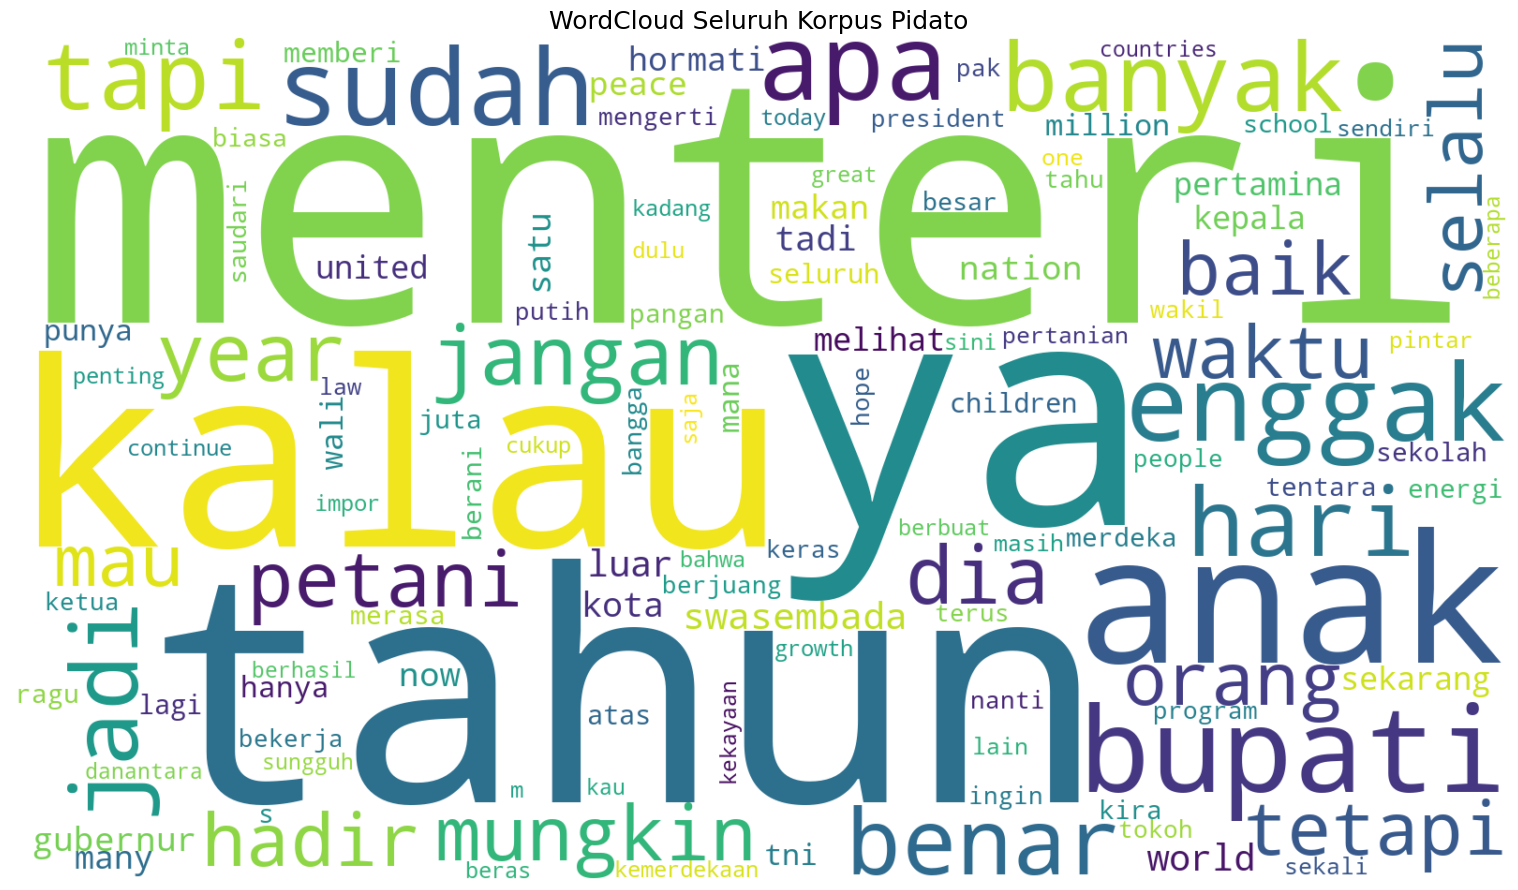

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_all_corpus.png


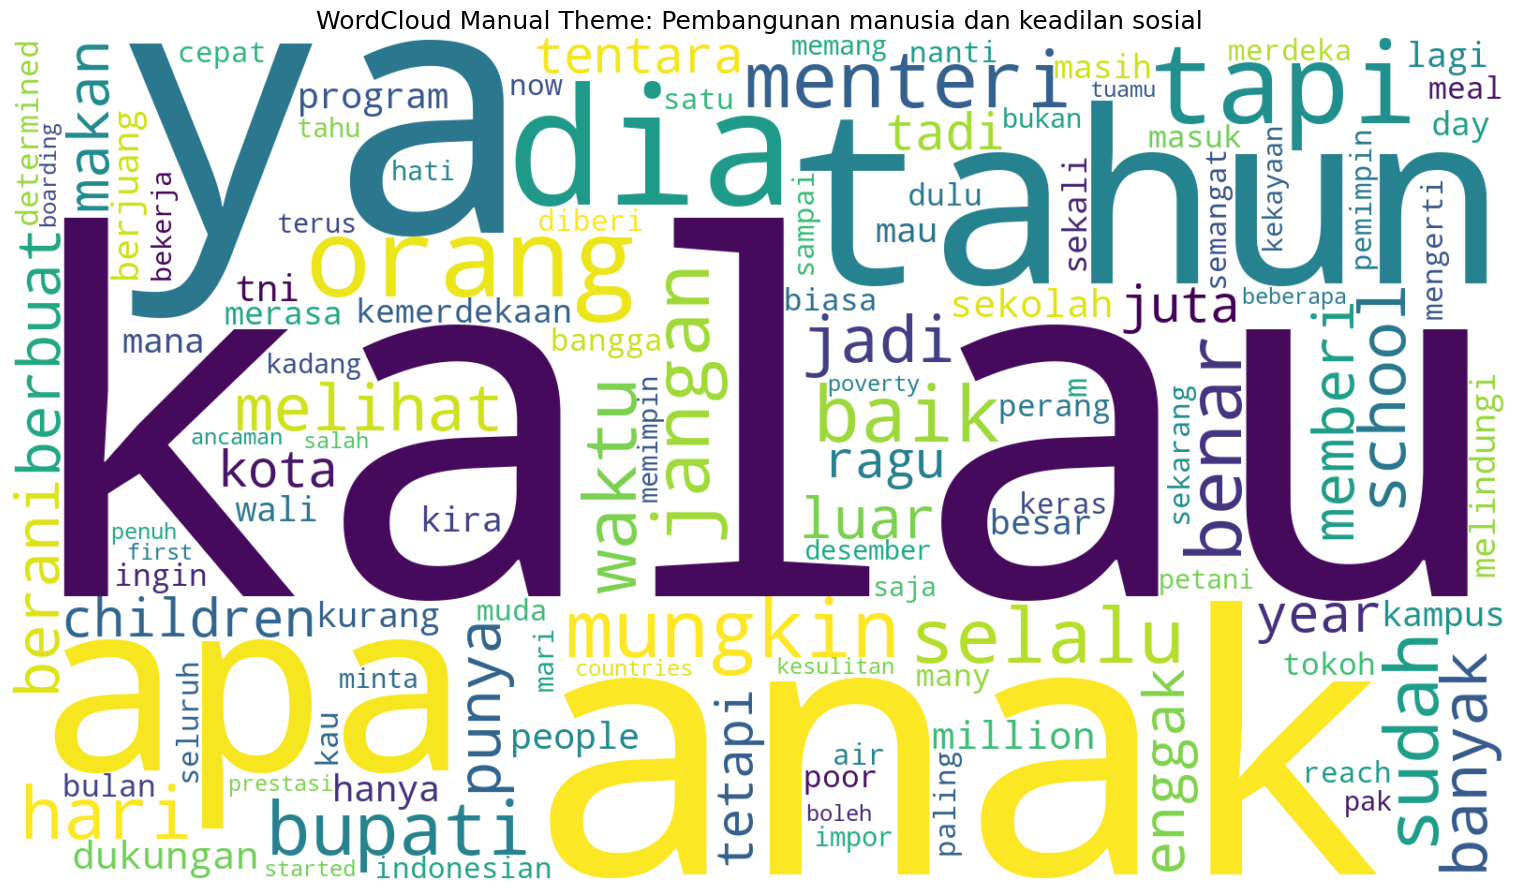

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_pembangunan_manusia_dan_keadilan_sosial.png


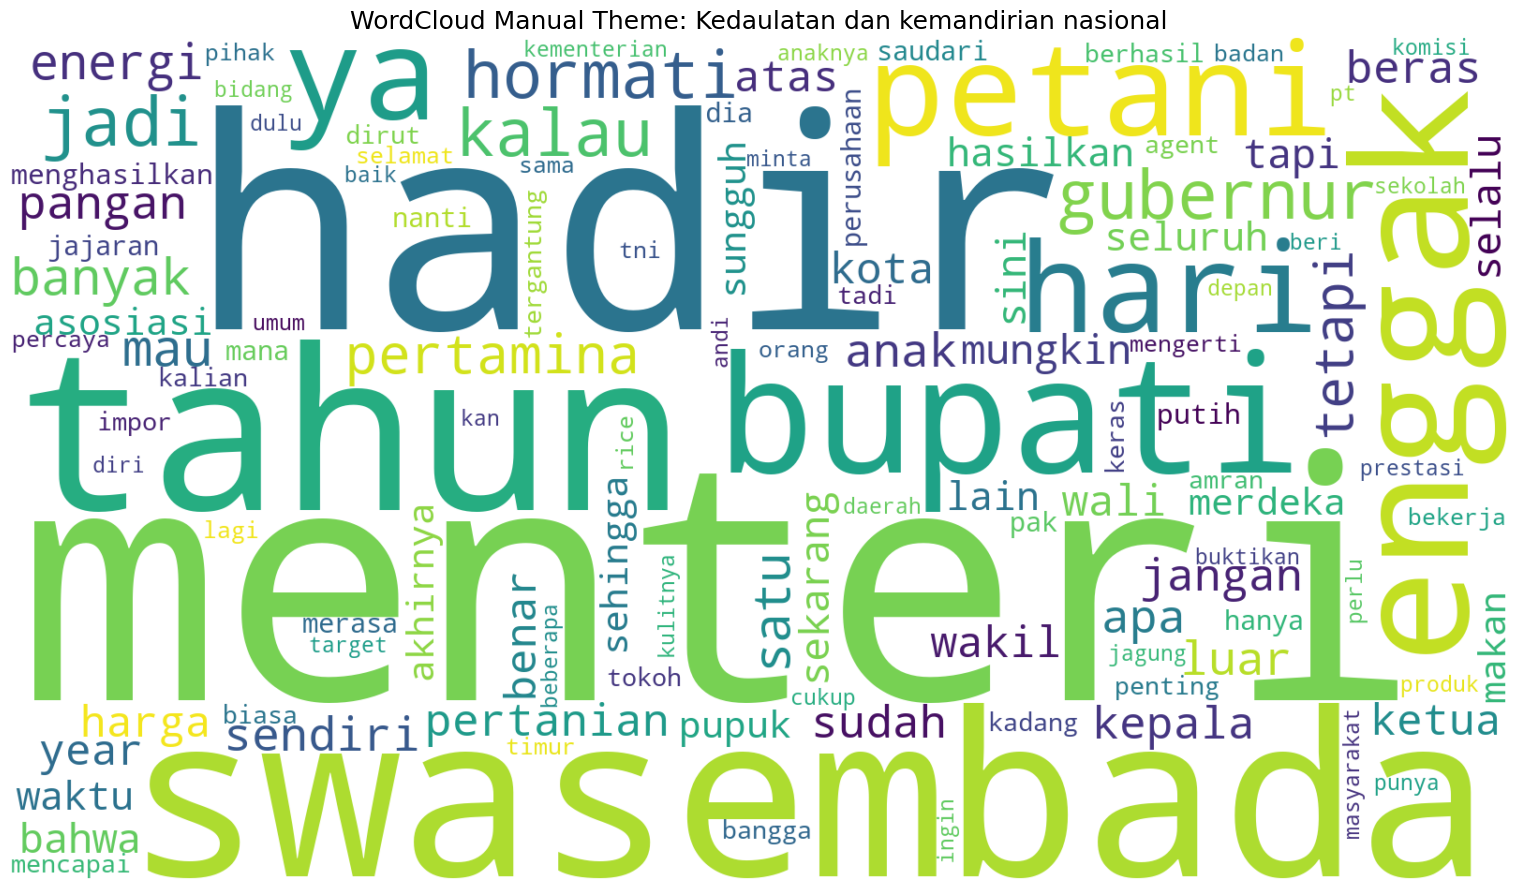

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_kedaulatan_dan_kemandirian_nasional.png


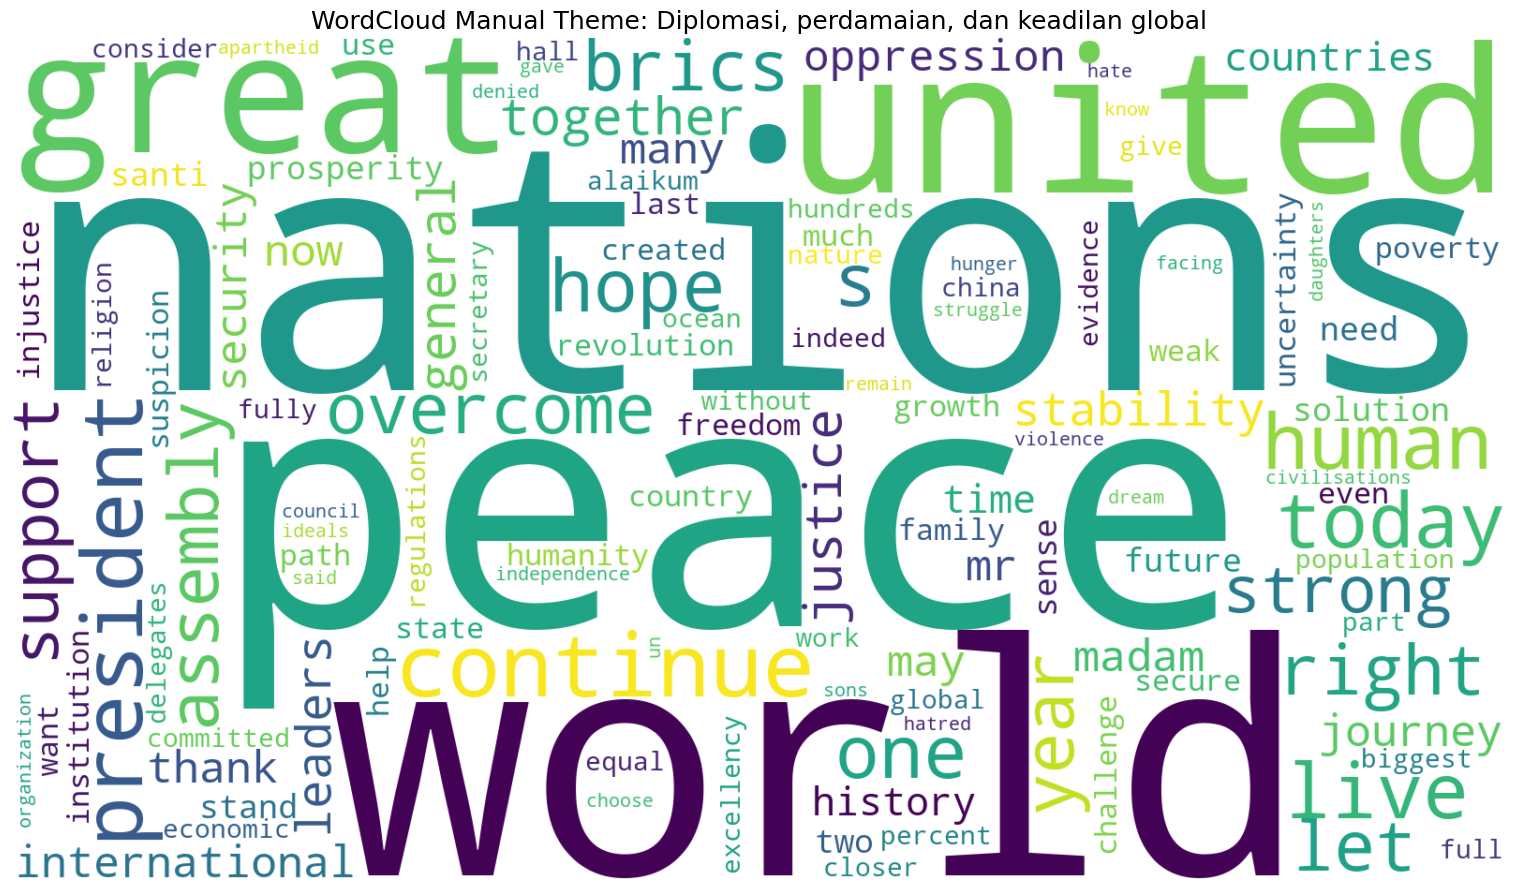

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_diplomasi_perdamaian_dan_keadilan_global.png


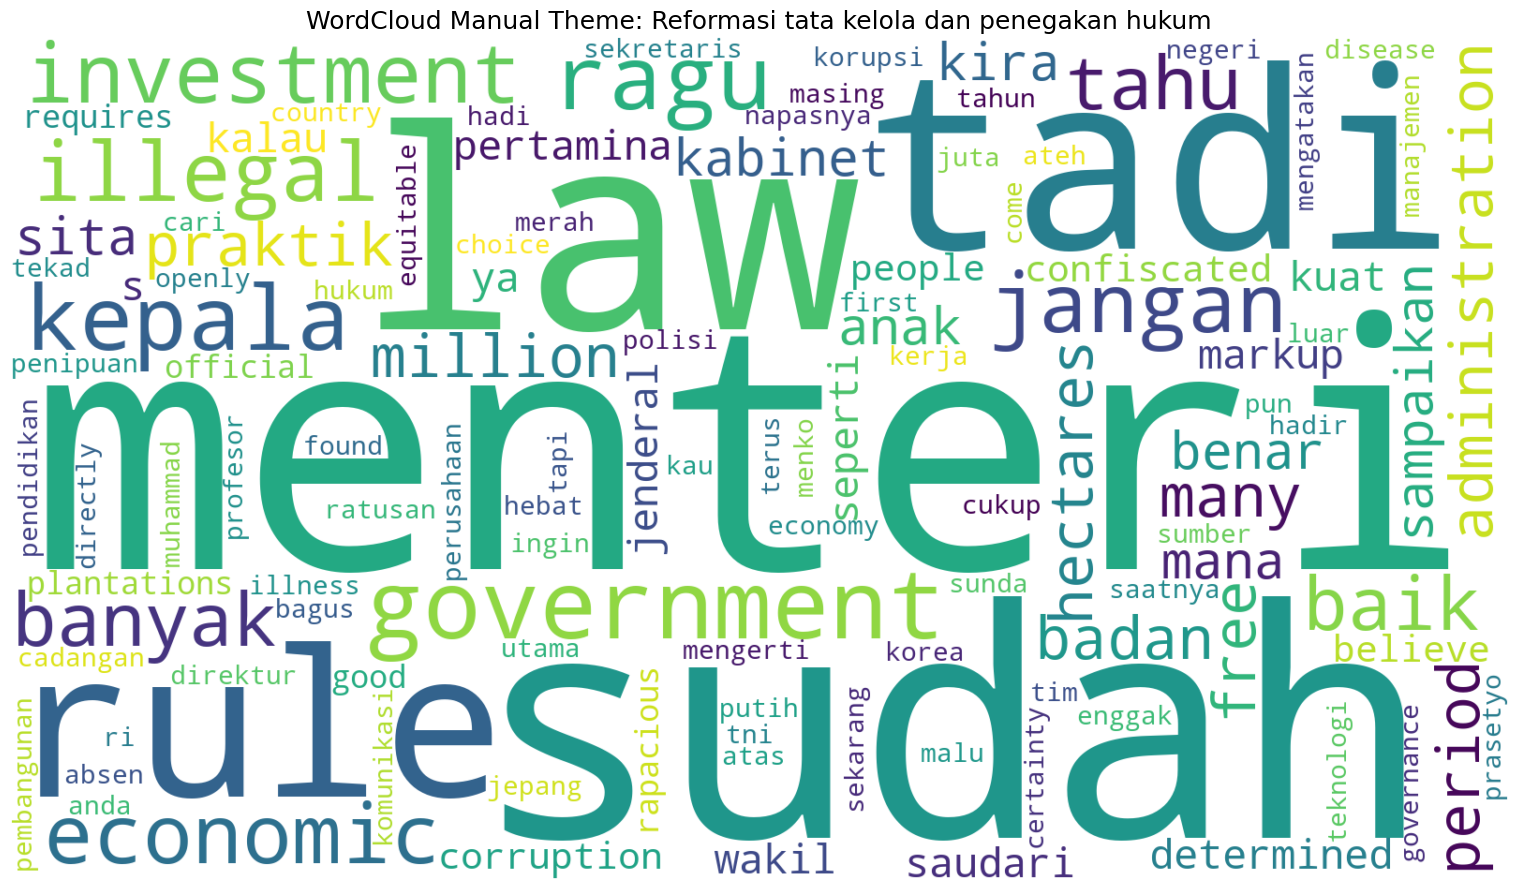

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_reformasi_tata_kelola_dan_penegakan_hukum.png


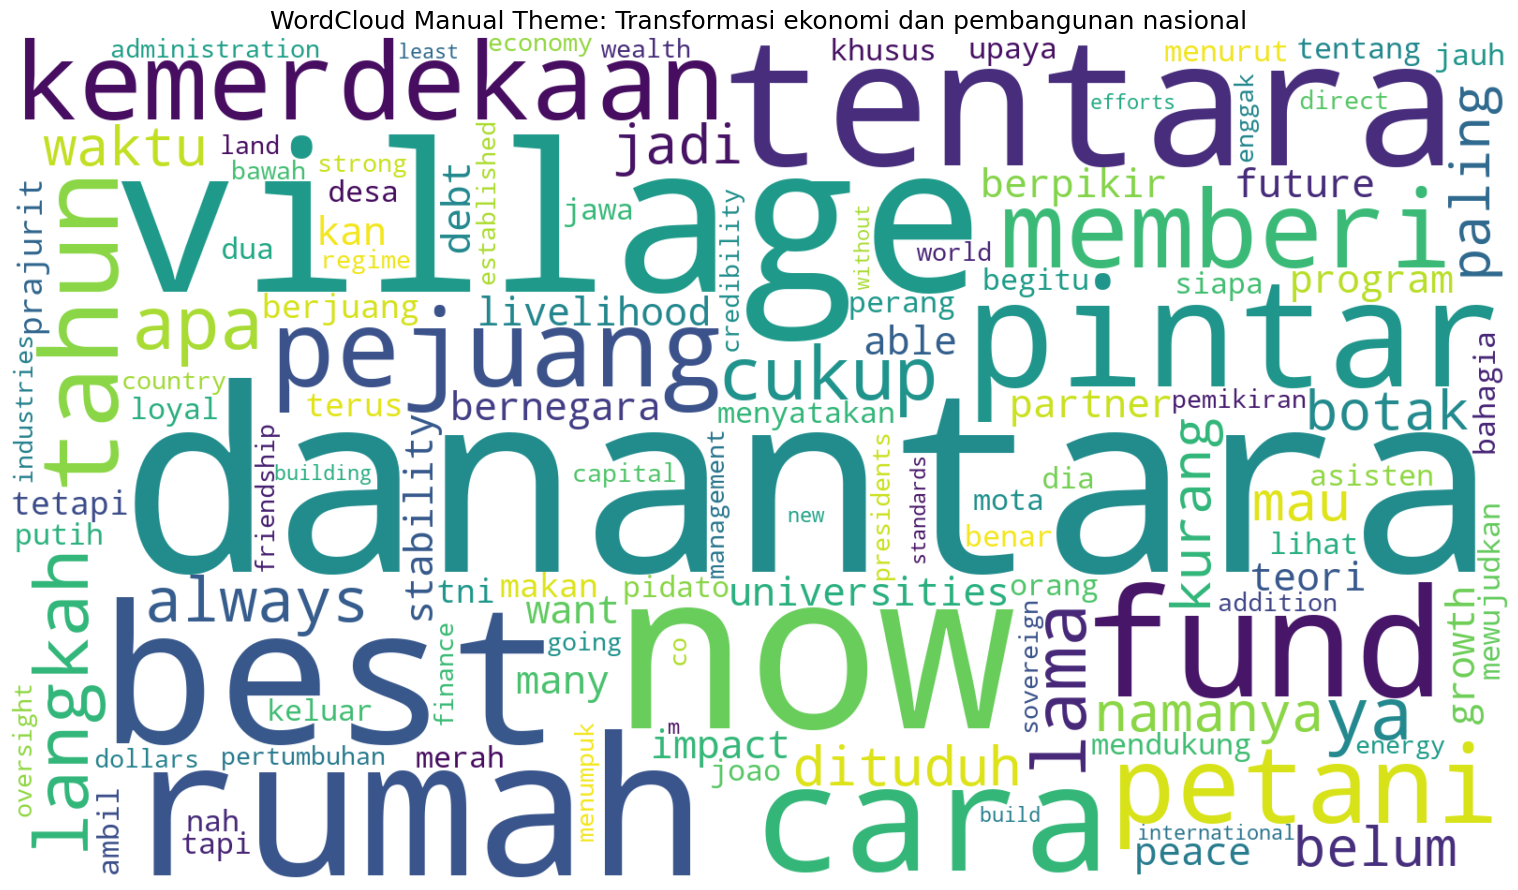

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_transformasi_ekonomi_dan_pembangunan_nasional.png


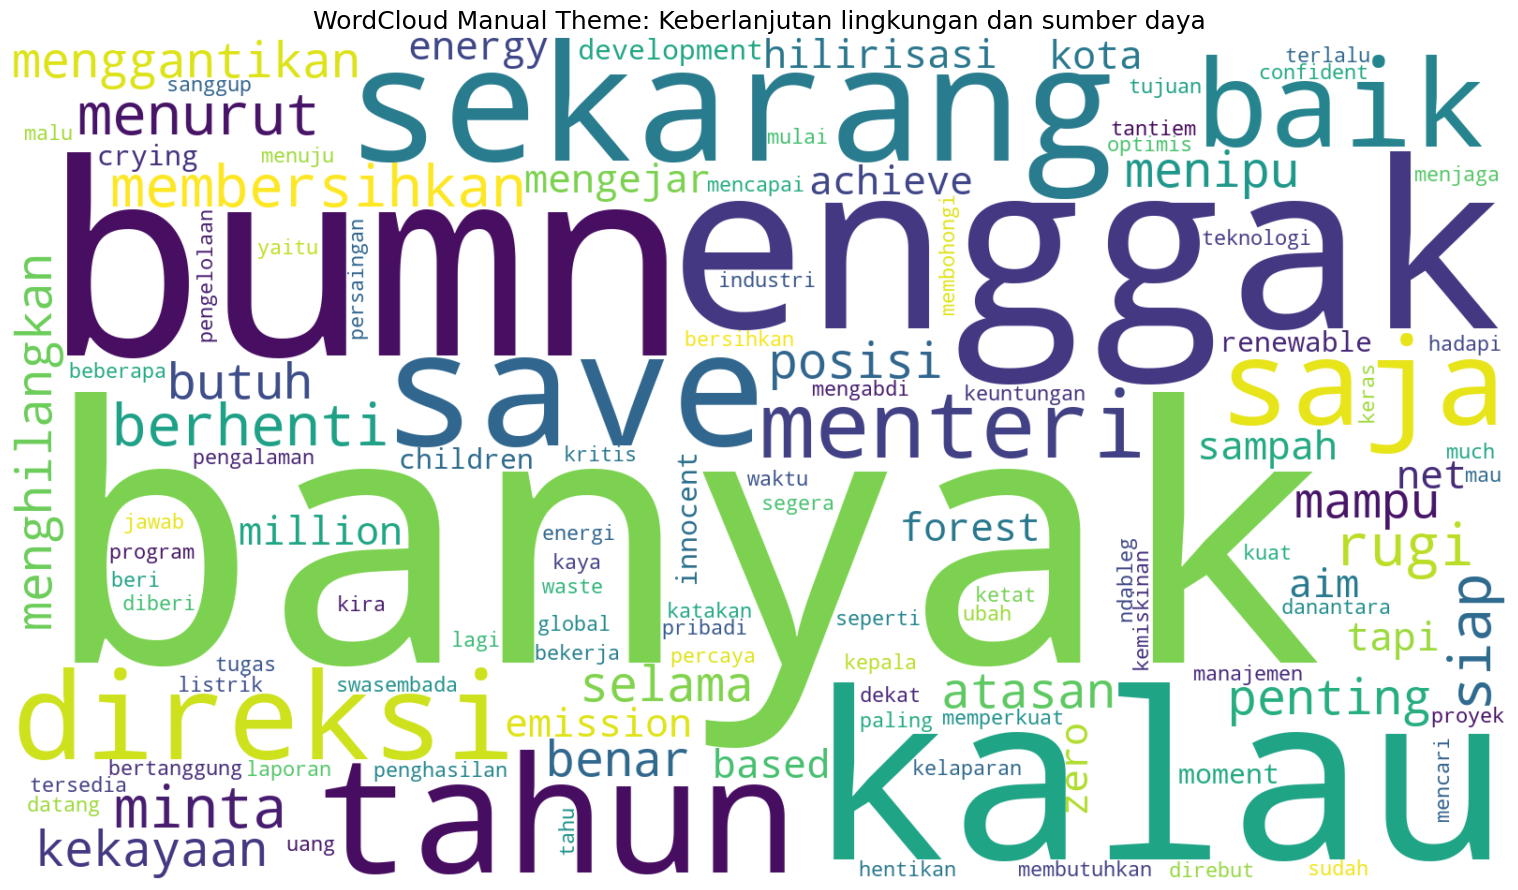

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_keberlanjutan_lingkungan_dan_sumber_daya.png


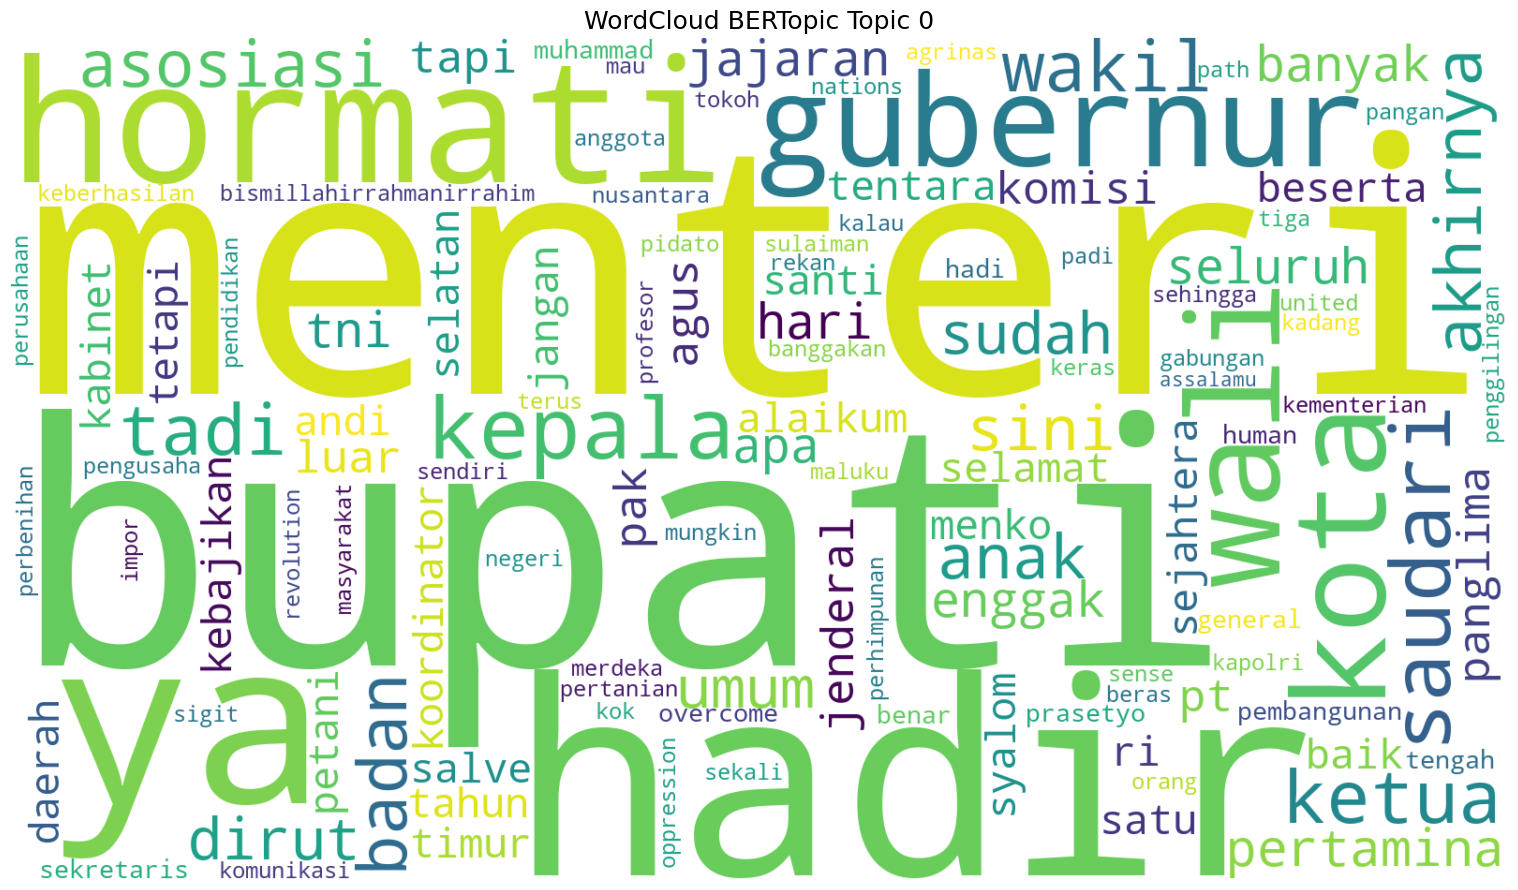

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_0.png


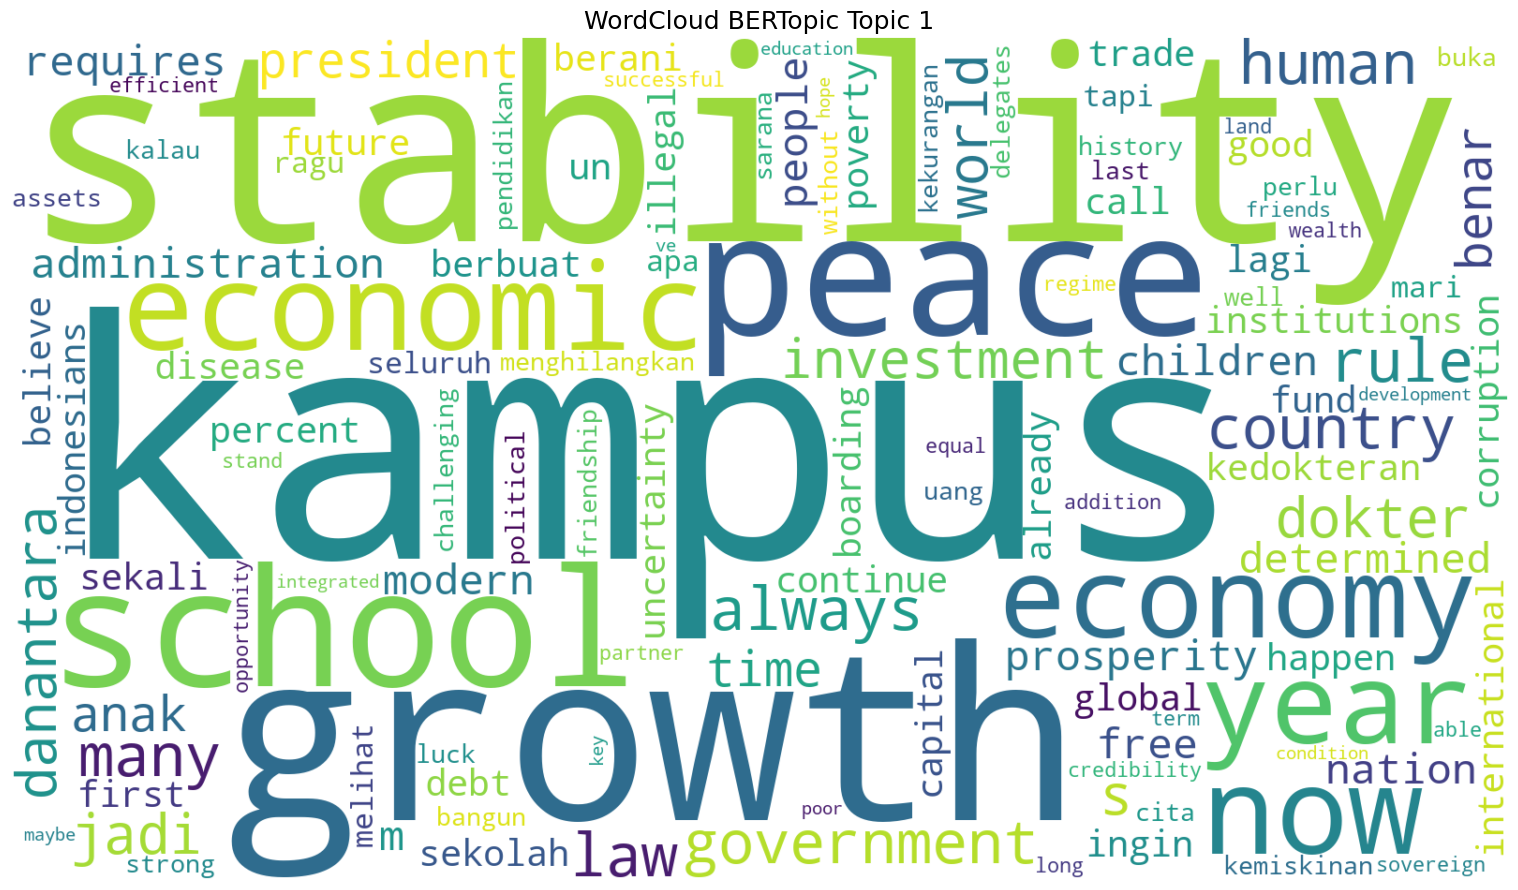

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_1.png


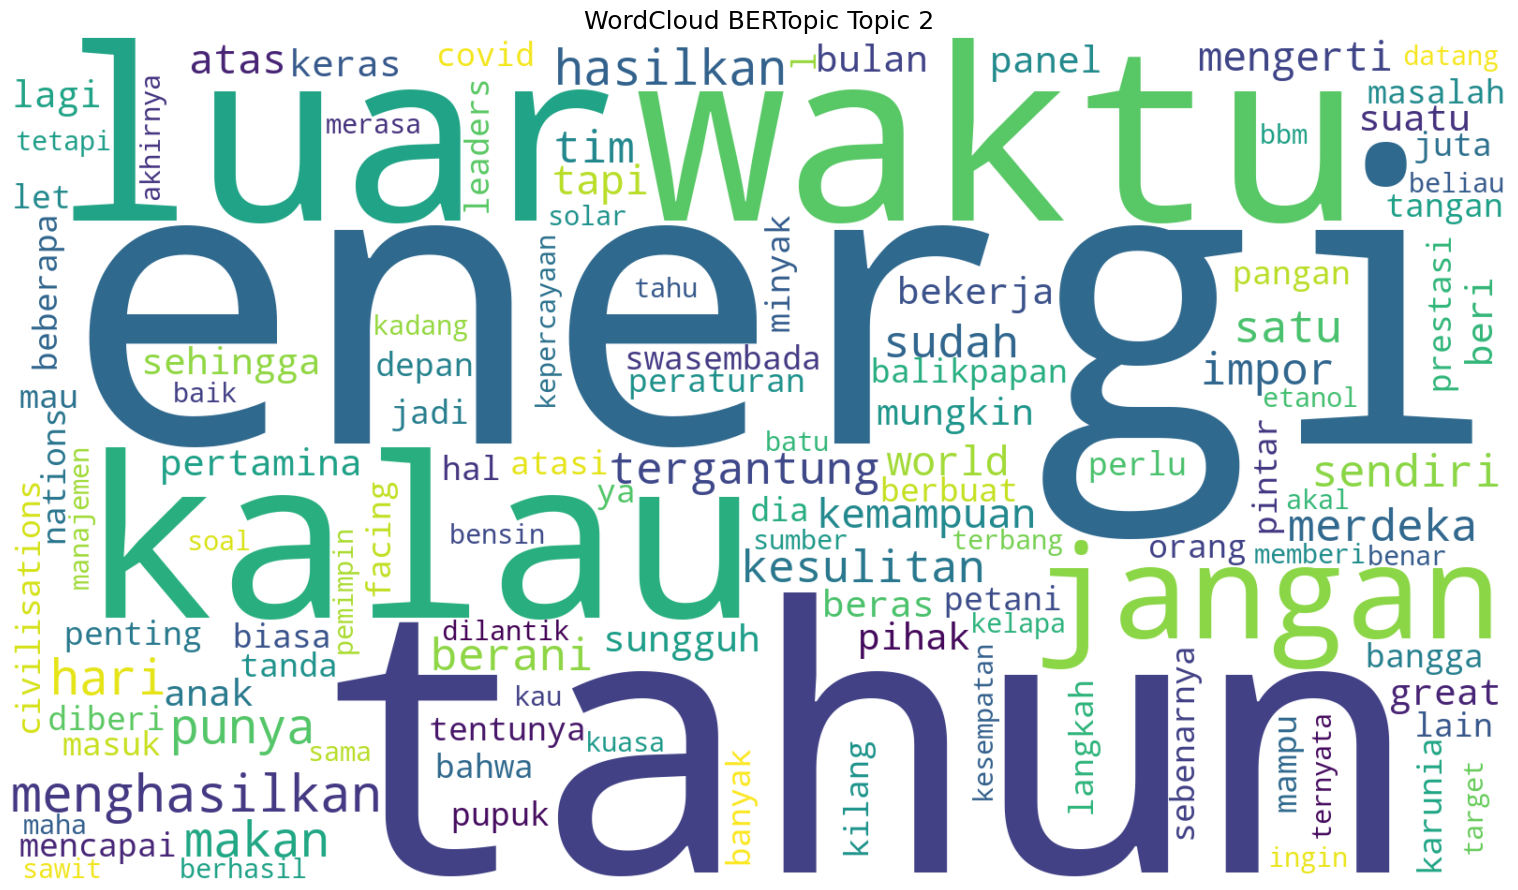

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_2.png


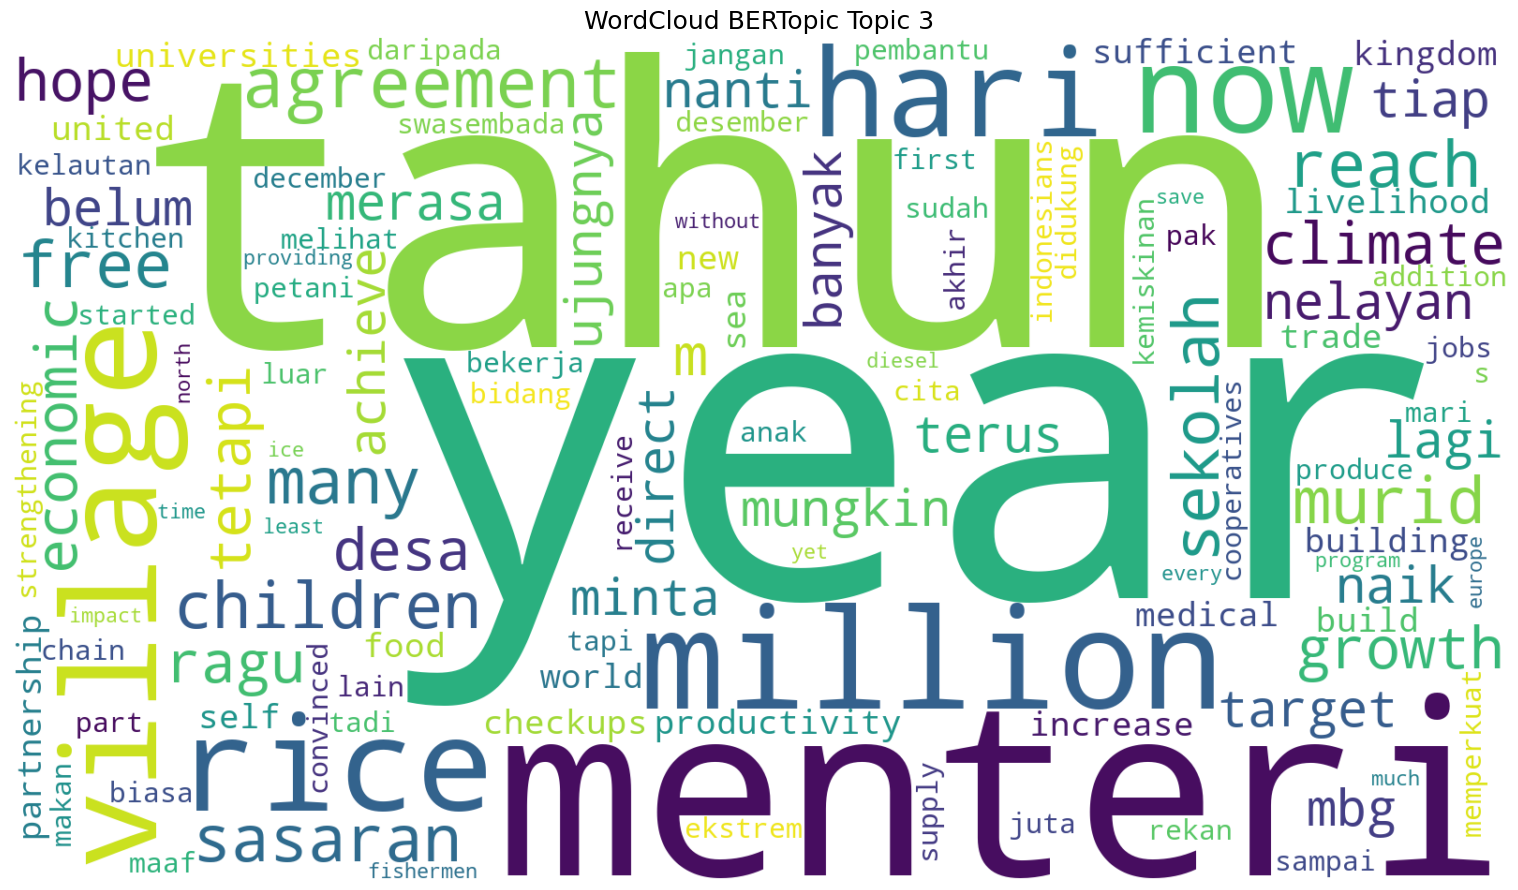

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_3.png


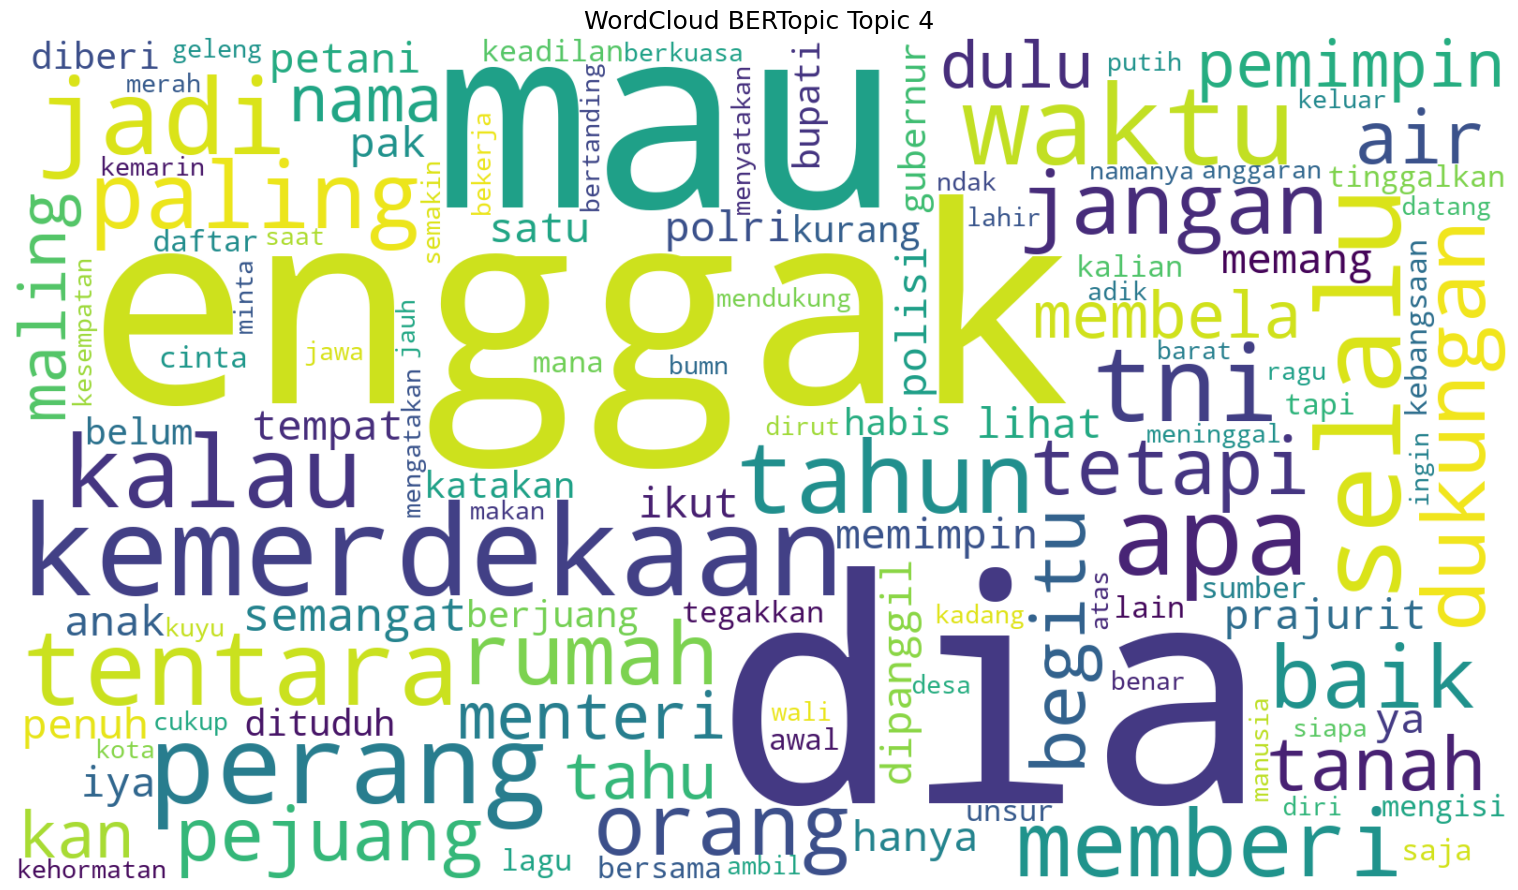

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_4.png


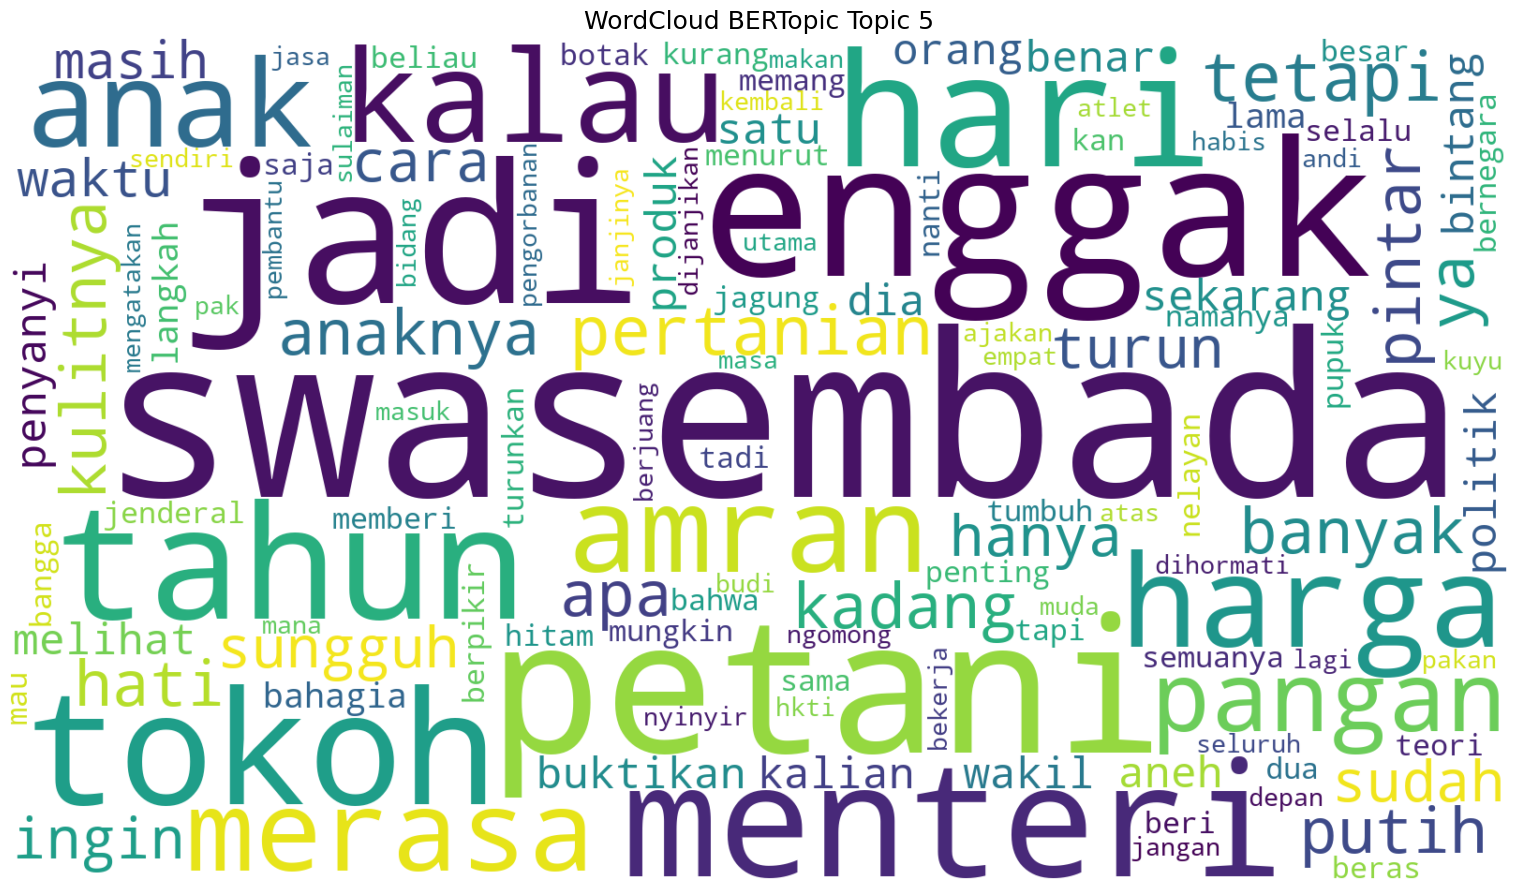

WordCloud berhasil disimpan: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_bertopic_topic_5.png
Ringkasan file WordCloud:
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_all_corpus.png
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_pembangunan_manusia_dan_keadilan_sosial.png
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_kedaulatan_dan_kemandirian_nasional.png
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_diplomasi_perdamaian_dan_keadilan_global.png
- D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\figures\final_wordcloud_manual_theme_reformasi_tata_kelola_dan_penegakan_hukum.png
- D:\DATA-KAMIL\MA

In [19]:
# ============================================================
# WordCloud Visualization
# ============================================================

AUTO_INSTALL_MISSING_PACKAGES = True

def ensure_package(module_name, package_name):
    if importlib.util.find_spec(module_name) is None:
        if AUTO_INSTALL_MISSING_PACKAGES:
            print(f"Package {package_name} belum tersedia. Instalasi dijalankan...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package_name])
        else:
            raise ImportError(f"Package {package_name} belum tersedia.")

ensure_package("wordcloud", "wordcloud")
ensure_package("matplotlib", "matplotlib")

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# ------------------------------------------------------------
# Stopwords tambahan Bahasa Indonesia dan istilah formal pidato
# ------------------------------------------------------------

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    # Bahasa Indonesia umum
    "yang", "dan", "di", "ke", "dari", "dengan", "untuk", "pada", "dalam",
    "ini", "itu", "adalah", "akan", "atau", "juga", "kita", "kami", "saya",
    "mereka", "sebagai", "karena", "telah", "tidak", "ada", "bisa", "dapat",
    "harus", "lebih", "sangat", "para", "sebuah", "secara", "menjadi",
    "oleh", "agar", "bagi", "kepada", "semua", "setiap", "namun",

    # Sapaan dan istilah formal pidato
    "bapak", "ibu", "saudara", "saudara-saudara", "hadirin", "sekalian",
    "hormat", "terhormat", "salam", "terima", "kasih", "assalamualaikum",
    "warahmatullahi", "wabarakatuh", "shalom", "om", "swastiastu",
    "namo", "buddhaya", "rahayu",

    # Nama dan istilah terlalu umum pada konteks pidato
    "presiden", "republik", "indonesia", "prabowo", "subianto",
    "negara", "bangsa", "rakyat",

    # Bahasa Inggris umum
    "the", "and", "of", "to", "in", "for", "with", "on", "as", "is",
    "are", "was", "were", "be", "been", "being", "we", "our", "us",
    "you", "your", "they", "their", "this", "that", "these", "those",
    "will", "would", "can", "could", "should", "must", "not", "have",
    "has", "had", "ladies", "gentlemen", "excellencies", "distinguished"
])

def clean_text_for_wordcloud(text):
    """
    Membersihkan teks untuk kebutuhan WordCloud.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def generate_wordcloud(text, title, output_path):
    """
    Membuat dan menyimpan WordCloud.
    """
    cleaned_text = clean_text_for_wordcloud(text)

    if len(cleaned_text.strip()) == 0:
        print(f"Teks kosong, WordCloud tidak dibuat: {title}")
        return

    wc = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        stopwords=custom_stopwords,
        collocations=False,
        max_words=120
    ).generate(cleaned_text)

    plt.figure(figsize=(16, 9))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"WordCloud berhasil disimpan: {output_path}")


# ------------------------------------------------------------
# 1. WordCloud seluruh korpus
# ------------------------------------------------------------

all_text = " ".join(comparative_df["text"].astype(str).tolist())

final_wordcloud_all_path = REPORT_FIGURE_DIR / "final_wordcloud_all_corpus.png"

generate_wordcloud(
    text=all_text,
    title="WordCloud Seluruh Korpus Pidato",
    output_path=final_wordcloud_all_path
)


# ------------------------------------------------------------
# 2. WordCloud berdasarkan Manual Selective Theme
# ------------------------------------------------------------

manual_theme_wordcloud_paths = []

top_manual_themes = (
    final_manual_theme_summary_df
    .sort_values("document_count", ascending=False)
    ["manual_selective_theme_clean"]
    .head(6)
    .tolist()
)

for theme in top_manual_themes:
    theme_df = comparative_df[
        comparative_df["manual_selective_theme_clean"] == theme
    ].copy()

    theme_text = " ".join(theme_df["text"].astype(str).tolist())

    safe_theme_name = (
        str(theme)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace(",", "")
        .replace("-", "_")
    )

    theme_wordcloud_path = REPORT_FIGURE_DIR / f"final_wordcloud_manual_theme_{safe_theme_name}.png"

    generate_wordcloud(
        text=theme_text,
        title=f"WordCloud Manual Theme: {theme}",
        output_path=theme_wordcloud_path
    )

    manual_theme_wordcloud_paths.append(str(theme_wordcloud_path))


# ------------------------------------------------------------
# 3. WordCloud berdasarkan BERTopic Topic terbesar
# ------------------------------------------------------------

bertopic_topic_wordcloud_paths = []

top_bertopic_topics = (
    final_bertopic_topic_summary_df
    .sort_values("topic_document_count", ascending=False)
    ["bertopic_topic_id"]
    .head(6)
    .tolist()
)

for topic_id in top_bertopic_topics:
    topic_df = comparative_df[
        comparative_df["bertopic_topic_id"].astype(str) == str(topic_id)
    ].copy()

    topic_text = " ".join(topic_df["text"].astype(str).tolist())

    topic_wordcloud_path = REPORT_FIGURE_DIR / f"final_wordcloud_bertopic_topic_{topic_id}.png"

    generate_wordcloud(
        text=topic_text,
        title=f"WordCloud BERTopic Topic {topic_id}",
        output_path=topic_wordcloud_path
    )

    bertopic_topic_wordcloud_paths.append(str(topic_wordcloud_path))


print("Ringkasan file WordCloud:")
print(f"- {final_wordcloud_all_path}")

for path in manual_theme_wordcloud_paths:
    print(f"- {path}")

for path in bertopic_topic_wordcloud_paths:
    print(f"- {path}")

## 12. Membuat Narasi Laporan Akhir dalam Markdown

Cell ini membuat file:

```text
reports/final_report_summary.md
```

File ini dapat digunakan sebagai bahan BAB Hasil dan Pembahasan.

In [12]:
# ============================================================
# Generate Final Report Summary Markdown
# ============================================================

def dataframe_to_markdown_safe(df, max_rows=20):
    """
    Konversi DataFrame ke Markdown dengan fallback jika tabulate tidak tersedia.
    """
    preview_df = df.head(max_rows).copy()

    try:
        return preview_df.to_markdown(index=False)
    except Exception:
        return preview_df.to_string(index=False)


key_findings_md = "\n".join(
    [
        f"- **{row['finding_title']}**: {row['finding_description']}"
        for _, row in final_key_findings_df.iterrows()
    ]
)

metrics_table_md = dataframe_to_markdown_safe(metrics_df)
manual_theme_table_md = dataframe_to_markdown_safe(final_manual_theme_summary_df)
bertopic_topic_table_md = dataframe_to_markdown_safe(final_bertopic_topic_summary_df)
comparative_table_md = dataframe_to_markdown_safe(final_comparative_interpretation_df)

final_report_summary_text = f"""# Ringkasan Laporan Akhir

## Judul

Analisis Komputasional Topik Pidato Presiden Prabowo pada Forum Nasional dan Internasional Menggunakan Manual Coding dan BERTopic

## Ringkasan Metode

Penelitian ini menggunakan dua pendekatan analisis topik, yaitu Manual Coding dan BERTopic. Manual Coding dilakukan melalui tahapan Open Coding, Axial Coding, dan Selective Coding. BERTopic digunakan sebagai pendekatan komputasional berbasis embedding dan clustering untuk menemukan pola topik secara otomatis dari data chunk pidato.

Dataset akhir terdiri dari chunk pidato yang telah melalui proses data inventory, text preprocessing, text chunking, manual coding, topic modeling, dan comparative analysis. Chunk yang berstatus EXCLUDED tidak digunakan dalam proses pemodelan BERTopic karena tidak mengandung substansi topik yang relevan.

## Temuan Kunci

{key_findings_md}

## Ringkasan Manual Coding

Manual Coding menghasilkan distribusi tema sebagai berikut:

{manual_theme_table_md}

## Ringkasan BERTopic

BERTopic menghasilkan ringkasan topik sebagai berikut:

{bertopic_topic_table_md}

## Metrik Perbandingan Manual Coding dan BERTopic

Metrik berikut digunakan karena BERTopic merupakan pendekatan unsupervised learning, sehingga tidak dievaluasi menggunakan accuracy klasifikasi biasa.

{metrics_table_md}

## Interpretasi Komparatif

Berikut ringkasan hubungan antara tema manual dan topik BERTopic:

{comparative_table_md}

## Kesimpulan Sementara

Hasil Manual Coding memberikan interpretasi tematik berbasis pembacaan peneliti, sedangkan BERTopic memberikan pengelompokan topik berbasis pola semantik dalam teks. Perbedaan antara keduanya wajar terjadi karena Manual Coding berfokus pada makna konseptual, sementara BERTopic berfokus pada kedekatan representasi embedding dan distribusi kata kunci.

Secara umum, kombinasi kedua pendekatan memberikan analisis yang lebih kuat. Manual Coding membantu menjelaskan konteks substantif, sedangkan BERTopic membantu menemukan pola topik secara komputasional dan memberi pembanding terhadap hasil interpretasi manual.
"""

final_report_summary_path = REPORTS_DIR / "final_report_summary.md"
final_report_summary_path.write_text(final_report_summary_text, encoding="utf-8")

print(f"Final report summary berhasil dibuat: {final_report_summary_path}")
print(final_report_summary_text[:1500])

Final report summary berhasil dibuat: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\final_report_summary.md
# Ringkasan Laporan Akhir

## Judul

Analisis Komputasional Topik Pidato Presiden Prabowo pada Forum Nasional dan Internasional Menggunakan Manual Coding dan BERTopic

## Ringkasan Metode

Penelitian ini menggunakan dua pendekatan analisis topik, yaitu Manual Coding dan BERTopic. Manual Coding dilakukan melalui tahapan Open Coding, Axial Coding, dan Selective Coding. BERTopic digunakan sebagai pendekatan komputasional berbasis embedding dan clustering untuk menemukan pola topik secara otomatis dari data chunk pidato.

Dataset akhir terdiri dari chunk pidato yang telah melalui proses data inventory, text preprocessing, text chunking, manual coding, topic modeling, dan comparative analysis. Chunk yang berstatus EXCLUDED tidak digunakan dalam proses pemodelan BERTopic karena tidak mengandung substansi topik yang relevan.

## Temuan Kunci

- **J

## 13. Membuat Catatan Presentasi dalam Markdown

Cell ini membuat file:

```text
reports/final_presentation_notes.md
```

File ini berisi poin-poin narasi untuk presentasi kelas.

In [15]:
# ============================================================
# Generate Final Presentation Notes Markdown
# ============================================================

presentation_notes_text = f"""# Catatan Presentasi Final

## Slide 1 — Judul

Project ini berjudul **Analisis Komputasional Topik Pidato Presiden Prabowo pada Forum Nasional dan Internasional Menggunakan Manual Coding dan BERTopic**.

Fokus utama project adalah membandingkan hasil analisis topik secara manual dengan hasil topic modeling otomatis menggunakan BERTopic.

## Slide 2 — Latar Belakang

Pidato politik dan kenegaraan memiliki banyak pesan strategis, seperti isu kedaulatan, pembangunan manusia, diplomasi, pangan, energi, pendidikan, dan tata kelola. Karena itu, diperlukan pendekatan analisis yang mampu menangkap tema secara sistematis.

## Slide 3 — Metodologi

Project ini mengikuti alur CRISP-DM secara sederhana:

1. Data understanding melalui inventory naskah pidato.
2. Data preparation melalui cleaning dan chunking.
3. Modeling melalui Manual Coding dan BERTopic.
4. Evaluation melalui comparative analysis.
5. Reporting melalui visualisasi dan interpretasi akhir.

## Slide 4 — Dataset

Dataset terdiri dari naskah pidato Presiden Prabowo pada forum nasional dan internasional. Setelah preprocessing dan chunking, data dianalisis pada level chunk agar unit analisis lebih konsisten.

Total chunk manual: {manual_total_chunk_count}.  
Chunk yang digunakan BERTopic: {bertopic_modeled_document_count}.  
Chunk yang dikeluarkan: {manual_excluded_chunk_count}.

## Slide 5 — Manual Coding

Manual Coding dilakukan dengan tiga tahap:

1. Open Coding untuk memberi label awal pada chunk.
2. Axial Coding untuk mengelompokkan kode ke kategori.
3. Selective Coding untuk menentukan tema utama.

Tema manual paling dominan adalah **{dominant_manual_theme}** dengan {dominant_manual_theme_count} chunk.

## Slide 6 — BERTopic

BERTopic digunakan untuk menemukan topik otomatis berbasis embedding dan clustering. Model menghasilkan {topic_count} label topik termasuk outlier, dengan {non_outlier_topic_count} topik non-outlier.

Topik terbesar adalah Topic {largest_topic_id}, dengan {largest_topic_count} chunk, dan dominan berkaitan dengan tema **{largest_topic_theme}**.

## Slide 7 — Comparative Analysis

Perbandingan dilakukan antara manual_selective_theme dan bertopic_topic_id. Metrik yang digunakan adalah NMI, AMI, Homogeneity, Completeness, dan V-measure.

Nilai NMI={nmi}, AMI={ami}, Homogeneity={homogeneity}, Completeness={completeness}, dan V-measure={v_measure}.

Metrik ini tidak dibaca sebagai accuracy, tetapi sebagai indikasi hubungan antara struktur tema manual dan cluster BERTopic.

## Slide 8 — Temuan Utama

{key_findings_md}

## Slide 9 — Interpretasi

Manual Coding lebih kuat dalam menangkap konteks substantif dan makna konseptual. BERTopic lebih kuat dalam menemukan pola kemiripan semantik secara otomatis. Perbedaan hasil keduanya wajar karena pendekatan manual dan komputasional bekerja dengan prinsip yang berbeda.

## Slide 10 — Kesimpulan

Kombinasi Manual Coding dan BERTopic memberikan hasil analisis topik yang lebih komprehensif. Manual Coding menyediakan validasi interpretatif, sedangkan BERTopic menyediakan pembanding komputasional. Pendekatan ini relevan untuk analisis teks pidato yang memiliki struktur topik kompleks.
"""

final_presentation_notes_path = REPORTS_DIR / "final_presentation_notes.md"
final_presentation_notes_path.write_text(presentation_notes_text, encoding="utf-8")

print(f"Final presentation notes berhasil dibuat: {final_presentation_notes_path}")
print(presentation_notes_text[:1500])

Final presentation notes berhasil dibuat: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\final_presentation_notes.md
# Catatan Presentasi Final

## Slide 1 — Judul

Project ini berjudul **Analisis Komputasional Topik Pidato Presiden Prabowo pada Forum Nasional dan Internasional Menggunakan Manual Coding dan BERTopic**.

Fokus utama project adalah membandingkan hasil analisis topik secara manual dengan hasil topic modeling otomatis menggunakan BERTopic.

## Slide 2 — Latar Belakang

Pidato politik dan kenegaraan memiliki banyak pesan strategis, seperti isu kedaulatan, pembangunan manusia, diplomasi, pangan, energi, pendidikan, dan tata kelola. Karena itu, diperlukan pendekatan analisis yang mampu menangkap tema secara sistematis.

## Slide 3 — Metodologi

Project ini mengikuti alur CRISP-DM secara sederhana:

1. Data understanding melalui inventory naskah pidato.
2. Data preparation melalui cleaning dan chunking.
3. Modeling melalui Manual Coding da

## 14. Validasi Akhir Output Tahap 07

Cell ini memastikan output final utama sudah terbentuk dan tidak kosong.

In [16]:
# ============================================================
# Final Validation
# ============================================================

outputs_to_validate = {
    "final_manual_theme_summary_df": final_manual_theme_summary_df,
    "final_bertopic_topic_summary_df": final_bertopic_topic_summary_df,
    "final_comparative_interpretation_df": final_comparative_interpretation_df,
    "final_key_findings_df": final_key_findings_df,
    "final_representative_evidence_df": final_representative_evidence_df
}

empty_outputs = [
    name for name, df in outputs_to_validate.items()
    if df is None or df.empty
]

if empty_outputs:
    raise ValueError(f"Output berikut kosong: {empty_outputs}")

required_report_files = [
    final_manual_theme_distribution_path,
    final_bertopic_topic_distribution_path,
    final_topic_purity_bar_path,
    final_comparative_heatmap_path,
    final_manual_theme_topic_alignment_path,
    final_report_summary_path,
    final_presentation_notes_path
]

missing_report_files = [
    str(path) for path in required_report_files
    if not Path(path).exists()
]

if missing_report_files:
    raise FileNotFoundError(f"Output file berikut belum ditemukan: {missing_report_files}")

print("Validasi akhir Tahap 07 berhasil.")

Validasi akhir Tahap 07 berhasil.


## 15. Menyimpan Output Tahap 07

Output final disimpan ke folder:

```text
reports/tables/
reports/figures/
reports/
```

In [17]:
# ============================================================
# Save Output Tahap 07
# ============================================================

final_manual_theme_summary_path = REPORT_TABLE_DIR / "final_manual_theme_summary.csv"
final_bertopic_topic_summary_path = REPORT_TABLE_DIR / "final_bertopic_topic_summary.csv"
final_comparative_interpretation_path = REPORT_TABLE_DIR / "final_comparative_interpretation.csv"
final_key_findings_path = REPORT_TABLE_DIR / "final_key_findings.csv"
final_representative_evidence_path = REPORT_TABLE_DIR / "final_representative_evidence.csv"
stage07_output_manifest_path = REPORT_TABLE_DIR / "stage07_output_manifest.json"

final_manual_theme_summary_df.to_csv(final_manual_theme_summary_path, index=False, encoding="utf-8-sig")
final_bertopic_topic_summary_df.to_csv(final_bertopic_topic_summary_path, index=False, encoding="utf-8-sig")
final_comparative_interpretation_df.to_csv(final_comparative_interpretation_path, index=False, encoding="utf-8-sig")
final_key_findings_df.to_csv(final_key_findings_path, index=False, encoding="utf-8-sig")
final_representative_evidence_df.to_csv(final_representative_evidence_path, index=False, encoding="utf-8-sig")

stage07_output_manifest = {
    "stage": "07_visualization_interpretation_final_reporting",
    "input_files": {
        "comparative_analysis_manual_vs_bertopic": str(INPUT_COMPARATIVE_ANALYSIS),
        "comparative_metrics_summary": str(INPUT_COMPARATIVE_METRICS),
        "bertopic_topic_manual_theme_mapping": str(INPUT_TOPIC_MANUAL_MAPPING),
        "manual_theme_bertopic_topic_mapping": str(INPUT_MANUAL_TOPIC_MAPPING),
        "comparative_narrative_summary": str(INPUT_NARRATIVE_SUMMARY),
        "representative_documents_by_topic": str(INPUT_REPRESENTATIVE_DOCS),
        "comparative_coverage_report": str(INPUT_COVERAGE_REPORT),
        "comparative_crosstab_theme_topic": str(INPUT_CROSSTAB),
        "comparative_crosstab_theme_topic_pct": str(INPUT_CROSSTAB_PCT)
    },
    "outputs": {
        "final_manual_theme_summary": str(final_manual_theme_summary_path),
        "final_bertopic_topic_summary": str(final_bertopic_topic_summary_path),
        "final_comparative_interpretation": str(final_comparative_interpretation_path),
        "final_key_findings": str(final_key_findings_path),
        "final_representative_evidence": str(final_representative_evidence_path),
        "final_manual_theme_distribution": str(final_manual_theme_distribution_path),
        "final_bertopic_topic_distribution": str(final_bertopic_topic_distribution_path),
        "final_topic_purity_bar": str(final_topic_purity_bar_path),
        "final_comparative_heatmap": str(final_comparative_heatmap_path),
        "final_manual_theme_topic_alignment": str(final_manual_theme_topic_alignment_path),
        "final_report_summary": str(final_report_summary_path),
        "final_presentation_notes": str(final_presentation_notes_path)
    },
    "summary": {
        "manual_total_chunk_count": int(manual_total_chunk_count),
        "manual_reviewed_chunk_count": int(manual_reviewed_chunk_count),
        "manual_excluded_chunk_count": int(manual_excluded_chunk_count),
        "bertopic_modeled_document_count": int(bertopic_modeled_document_count),
        "bertopic_topic_count_including_outlier": int(topic_count),
        "bertopic_topic_count_excluding_outlier": int(non_outlier_topic_count),
        "outlier_document_count": int(outlier_topic_count),
        "dominant_manual_theme": str(dominant_manual_theme),
        "largest_bertopic_topic_id": str(largest_topic_id)
    },
    "metrics": {
        "normalized_mutual_information": nmi,
        "adjusted_mutual_information": ami,
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure
    },
    "created_at": datetime.now().isoformat(timespec="seconds")
}

stage07_output_manifest_path.write_text(
    json.dumps(stage07_output_manifest, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8"
)

print("Output Tahap 07 berhasil disimpan:")
print(f"1. {final_manual_theme_summary_path}")
print(f"2. {final_bertopic_topic_summary_path}")
print(f"3. {final_comparative_interpretation_path}")
print(f"4. {final_key_findings_path}")
print(f"5. {final_representative_evidence_path}")
print(f"6. {stage07_output_manifest_path}")
print(f"7. {final_report_summary_path}")
print(f"8. {final_presentation_notes_path}")

Output Tahap 07 berhasil disimpan:
1. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\final_manual_theme_summary.csv
2. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\final_bertopic_topic_summary.csv
3. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\final_comparative_interpretation.csv
4. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\final_key_findings.csv
5. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\final_representative_evidence.csv
6. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\tables\stage07_output_manifest.json
7. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\final_report_summary.md
8. D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\topic-modeling-prabowo-un-speech\reports\final_pr

## 16. Preview Output Final

Cell ini menampilkan ringkasan akhir sebelum notebook ditutup.

In [18]:
# ============================================================
# Preview Output Final
# ============================================================

print("Final Key Findings:")
display(final_key_findings_df)

print("Final Manual Theme Summary:")
display(final_manual_theme_summary_df)

print("Final BERTopic Topic Summary:")
display(final_bertopic_topic_summary_df)

print("Final Comparative Interpretation:")
display(final_comparative_interpretation_df)

print("Final Representative Evidence:")
display(final_representative_evidence_df.head(15))

Final Key Findings:


,finding_id,finding_title,finding_description
0,KF01,Jumlah data analisis final,"Manual Coding mencakup 74 chunk, dengan 71 chu..."
1,KF02,Tema manual paling dominan,Tema manual paling dominan adalah 'Pembangunan...
2,KF03,Jumlah topik BERTopic,BERTopic menghasilkan 15 label topik termasuk ...
3,KF04,Topik BERTopic terbesar,Topik BERTopic terbesar adalah Topic 0 dengan ...
4,KF05,Tema dengan alignment terkuat,Alignment terkuat muncul pada tema manual 'Keb...
5,KF06,Kesesuaian Manual Coding dan BERTopic,"Metrik clustering menunjukkan NMI=0.334, AMI=0..."


Final Manual Theme Summary:


,manual_selective_theme_clean,document_count,unique_speech_count,unique_bertopic_topic_count,avg_bertopic_probability,document_percentage
0,Pembangunan manusia dan keadilan sosial,24,4,12,0.6661,33.80
1,Kedaulatan dan kemandirian nasional,22,5,8,0.7423,30.99
2,"Diplomasi, perdamaian, dan keadilan global",12,3,6,0.8664,16.90
3,Reformasi tata kelola dan penegakan hukum,6,4,5,0.7384,8.45
4,Transformasi ekonomi dan pembangunan nasional,5,3,5,0.8337,7.04
5,Keberlanjutan lingkungan dan sumber daya,2,2,2,0.5499,2.82


Final BERTopic Topic Summary:


,bertopic_topic_id,dominant_manual_selective_theme,dominant_theme_count,topic_document_count,topic_purity,Name,auto_topic_label,top_keywords,topic_type
0,0,Kedaulatan dan kemandirian nasional,8,13,0.6154,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota,"bupati, hadir, menteri, hormati, wali kota, wa...",Cluster
1,1,"Diplomasi, perdamaian, dan keadilan global",2,7,0.2857,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,"kampus, stability, growth, peace stability, ov...",Cluster
2,2,Kedaulatan dan kemandirian nasional,4,6,0.6667,2_energi_menghasilkan_kesulitan_hasilkan,energi / menghasilkan / kesulitan / hasilkan /...,"energi, menghasilkan, kesulitan, hasilkan, ter...",Cluster
3,3,Kedaulatan dan kemandirian nasional,3,6,0.5000,3_000_rice_years_000 murid,000 / rice / years / 000 murid / 83,"000, rice, years, 000 murid, 83, 83 000, sasar...",Cluster
4,4,Pembangunan manusia dan keadilan sosial,3,5,0.6000,4_kemerdekaan_dia_perang_mau,kemerdekaan / dia / perang / mau / enggak,"kemerdekaan, dia, perang, mau, enggak, rakyat,...",Cluster
5,5,Kedaulatan dan kemandirian nasional,3,5,0.6000,5_swasembada_amran_harga_tokoh,swasembada / amran / harga / tokoh / kulitnya,"swasembada, amran, harga, tokoh, kulitnya, jad...",Cluster
6,6,Pembangunan manusia dan keadilan sosial,4,4,1.0000,6_anak_orang tuamu_tuamu_son,anak / orang tuamu / tuamu / son / kau,"anak, orang tuamu, tuamu, son, kau, ya, anak a...",Cluster
7,7,"Diplomasi, perdamaian, dan keadilan global",4,4,1.0000,7_united nations_nations_united_peace,united nations / nations / united / peace / all,"united nations, nations, united, peace, all, t...",Cluster
8,8,Pembangunan manusia dan keadilan sosial,3,4,0.7500,8_koperasi_meals_day_guru,koperasi / meals / day / guru / desember,"koperasi, meals, day, guru, desember, ribu, ko...",Cluster
9,9,"Diplomasi, perdamaian, dan keadilan global",2,3,0.6667,9_brics_best_danantara_now,brics / best / danantara / now / biggest,"brics, best, danantara, now, biggest, fully su...",Cluster


Final Comparative Interpretation:


,manual_selective_theme_clean,dominant_bertopic_topic_id,dominant_topic_count,theme_document_count,theme_concentration,dominant_bertopic_topic_name,auto_topic_label,alignment_level,interpretation_note
0,Pembangunan manusia dan keadilan sosial,6,4,24,0.1667,6_anak_orang tuamu_tuamu_son,anak / orang tuamu / tuamu / son / kau,Lemah,Tema manual 'Pembangunan manusia dan keadilan ...
1,Kedaulatan dan kemandirian nasional,0,8,22,0.3636,0_bupati_hadir_menteri_hormati,bupati / hadir / menteri / hormati / wali kota,Lemah,Tema manual 'Kedaulatan dan kemandirian nasion...
2,"Diplomasi, perdamaian, dan keadilan global",7,4,12,0.3333,7_united nations_nations_united_peace,united nations / nations / united / peace / all,Lemah,"Tema manual 'Diplomasi, perdamaian, dan keadil..."
3,Reformasi tata kelola dan penegakan hukum,1,2,6,0.3333,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,Lemah,Tema manual 'Reformasi tata kelola dan penegak...
4,Transformasi ekonomi dan pembangunan nasional,1,1,5,0.2000,1_kampus_stability_growth_peace stability,kampus / stability / growth / peace stability ...,Lemah,Tema manual 'Transformasi ekonomi dan pembangu...
5,Keberlanjutan lingkungan dan sumber daya,-1,1,2,0.5000,-1_melindungi_ancaman_melindungi ancaman_pertu...,Outlier / tidak terklaster,Sedang,Tema manual 'Keberlanjutan lingkungan dan sumb...


Final Representative Evidence:


,doc_id,speech_id,chunk_order,bertopic_topic_id,bertopic_topic_name,bertopic_topic_probability,manual_open_code_1,manual_axial_category,manual_selective_theme,text_excerpt
0,SPCH_006_PBB_80_CHK_006,SPCH_006_PBB_80,6,-1,-1_melindungi_ancaman_melindungi ancaman_pertu...,0.099832,"Lingkungan, iklim, dan keberlanjutan",Ketahanan lingkungan dan keberlanjutan,Keberlanjutan lingkungan dan sumber daya,We aim to achieve net zero emission by 2060 an...
1,SPCH_004_PERESMIAN_166_SEKOLAH_CHK_006,SPCH_004_PERESMIAN_166_SEKOLAH,6,-1,-1_melindungi_ancaman_melindungi ancaman_pertu...,0.086919,Pemerataan kesejahteraan dan pengentasan kemis...,Kesejahteraan sosial dan pemerataan pembangunan,Pembangunan manusia dan keadilan sosial,"Nah, ini teori, tapi kenyataannya menetesnya k..."
2,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_001,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,1,0,0_bupati_hadir_menteri_hormati,1.000000,Kedaulatan energi dan pengelolaan sumber daya,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Bismillahirrahmanirrahim. Assalamu'alaikum war...
3,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_012,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,12,0,0_bupati_hadir_menteri_hormati,1.000000,Kedaulatan energi dan pengelolaan sumber daya,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Advanced technology ini dipimpin oleh seorang ...
4,SPCH_004_PERESMIAN_166_SEKOLAH_CHK_001,SPCH_004_PERESMIAN_166_SEKOLAH,1,0,0_bupati_hadir_menteri_hormati,1.000000,Persatuan nasional dan kepercayaan diri bangsa,Identitas nasional dan kepemimpinan,Kedaulatan dan kemandirian nasional,"Bismillahirrahmanirrahim, Assalamu'alaikum war..."
7,SPCH_005_WORLD_ECONOMIC_FORUM_CHK_001,SPCH_005_WORLD_ECONOMIC_FORUM,1,1,1_kampus_stability_growth_peace stability,1.000000,Diplomasi multilateral dan kerja sama internas...,Diplomasi dan tatanan global,"Diplomasi, perdamaian, dan keadilan global","Distinguished President and CEO of the WEF, Mr..."
8,SPCH_005_WORLD_ECONOMIC_FORUM_CHK_002,SPCH_005_WORLD_ECONOMIC_FORUM,2,1,1_kampus_stability_growth_peace stability,1.000000,"Investasi, industrialisasi, dan pertumbuhan ek...",Transformasi ekonomi dan pembangunan produktif,Transformasi ekonomi dan pembangunan nasional,Peace and stability in my country did not happ...
9,SPCH_006_PBB_80_CHK_002,SPCH_006_PBB_80,2,1,1_kampus_stability_growth_peace stability,1.000000,Diplomasi multilateral dan kerja sama internas...,Diplomasi dan tatanan global,"Diplomasi, perdamaian, dan keadilan global","Human folly, fueled by fear, racism, hatred, o..."
12,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_004,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,4,2,2_energi_menghasilkan_kesulitan_hasilkan,1.000000,Kedaulatan pangan dan swasembada,Ketahanan nasional dan kedaulatan strategis,Kedaulatan dan kemandirian nasional,Juga kemampuan kita di energi dari air dan jug...
13,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI_CHK_006,SPCH_003_PERESMIAN_INFRASTRUKTUR_ENERGI,6,2,2_energi_menghasilkan_kesulitan_hasilkan,1.000000,Persatuan nasional dan kepercayaan diri bangsa,Identitas nasional dan kepemimpinan,Kedaulatan dan kemandirian nasional,"Di setiap bidang kehidupan, kita harus menjadi..."


## 17. Interpretasi Akhir

Tahap 07 menghasilkan paket output final untuk laporan dan presentasi.

Hasil yang paling penting:

1. `final_key_findings.csv` berisi temuan utama.
2. `final_report_summary.md` berisi narasi laporan akhir.
3. `final_presentation_notes.md` berisi catatan presentasi.
4. Visualisasi HTML pada `reports/figures/` dapat digunakan sebagai pendukung presentasi.
5. Tabel final pada `reports/tables/` dapat digunakan untuk BAB Hasil dan Pembahasan.

## Tahap Berikutnya

Tahap berikutnya bersifat opsional tetapi sangat direkomendasikan:

```text
Tahap 08 — Final Packaging GitHub, README, dan Executive Summary
```